# EDA - Credit Risk Dataset

## Etape 1 - Charger les librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Affichage propre des graphiques dans le notebook
%matplotlib inline

# Limiter les avertissements inutiles
import warnings
warnings.filterwarnings('ignore')

print('Librairies chargees avec succes')

Librairies chargees avec succes


On importe pandas pour manipuler les données, numpy pour les calculs numériques, matplotlib et seaborn pour les visualisations. warnings.filterwarnings évite d'encombrer la sortie avec des messages non critiques.

## Etape 2 - Charger le dataset

In [2]:
# Adapter le chemin selon votre machine
chemin = r'C:\Users\jason\Downloads\archive(23)\credit_risk_dataset.csv'

df = pd.read_csv(chemin)

print('Dataset charge.')
print('Nombre de lignes :', df.shape[0])
print('Nombre de colonnes :', df.shape[1])

Dataset charge.
Nombre de lignes : 32581
Nombre de colonnes : 12


pd.read_csv charge le fichier en mémoire dans un DataFrame. On affiche le nombre de lignes et colonnes pour confirmer que le fichier s'est chargé correctement et qu'aucune donnée n'a été tronquée.

## Etape 3 - Apercu du dataset

In [3]:
# Premieres lignes
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


df.head() retourne les 5 premières lignes. C'est le premier regard sur les données brutes — on vérifie que les colonnes sont bien séparées et que les valeurs ont l'air cohérentes.

In [4]:
# Dernieres lignes
df.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


df.tail() affiche les dernières lignes pour s'assurer que le fichier n'est pas coupé et que les données de fin sont dans le même format que le début.

In [5]:
# Dimensions
print('Shape :', df.shape)

# Noms des colonnes
print('\nColonnes :')
print(df.columns.tolist())

Shape : (32581, 12)

Colonnes :
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


df.shape retourne un tuple (lignes, colonnes). On affiche aussi les noms de colonnes pour avoir une vue d'ensemble avant d'aller plus loin.

## Etape 4 - Types des colonnes

In [6]:
# Types de chaque colonne
print(df.dtypes)
print()

# Infos generales
df.info()

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade      

df.dtypes indique comment pandas a interprété chaque colonne. df.info() complète avec le nombre de valeurs non nulles. On vérifie que les colonnes numériques ne sont pas en object, ce qui signalerait un problème de lecture.

## Etape 5 - Nettoyage de la structure

In [7]:
# Supprimer les espaces dans les noms de colonnes
df.columns = df.columns.str.strip()

print('Noms de colonnes apres nettoyage :')
print(df.columns.tolist())

Noms de colonnes apres nettoyage :
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


str.strip() supprime les espaces en début et fin de chaque nom de colonne. Un espace invisible provoque un KeyError quand on appelle df['person_age'] si la colonne s'appelle réellement 'person_age '.

In [8]:
# Verifier les valeurs uniques des colonnes categorielles
colonnes_cat = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

for col in colonnes_cat:
    print(f'{col} : {df[col].unique()}')

person_home_ownership : ['RENT' 'OWN' 'MORTGAGE' 'OTHER']
loan_intent : ['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
loan_grade : ['D' 'B' 'C' 'A' 'E' 'F' 'G']
cb_person_default_on_file : ['Y' 'N']


On boucle sur les colonnes texte et on affiche leurs valeurs uniques avec unique(). Cela permet de repérer des incohérences de casse ou de format comme 'RENT' et 'rent' qui seraient traitées comme deux catégories différentes.

## Etape 6 - Identifier la cible et les features

In [9]:
# Variable cible
cible = 'loan_status'

# Variables explicatives
features = [col for col in df.columns if col != cible]

print('Cible :', cible)
print('\nFeatures :')
print(features)

Cible : loan_status

Features :
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


On isole loan_status comme variable cible et on liste les autres colonnes comme features. Cette séparation est nécessaire pour éviter d'intégrer la cible dans les variables d'entrainement.

## Etape 8 - Valeurs manquantes

In [10]:
# Nombre de valeurs manquantes par colonne
valeurs_manquantes = df.isnull().sum()

# Pourcentage
pct_manquantes = (df.isnull().sum() / len(df)) * 100

# Tableau de synthese
tableau_manquants = pd.DataFrame({
    'Nombre manquants': valeurs_manquantes,
    'Pourcentage (%)': pct_manquantes.round(2)
})

print(tableau_manquants)

                            Nombre manquants  Pourcentage (%)
person_age                                 0             0.00
person_income                              0             0.00
person_home_ownership                      0             0.00
person_emp_length                        895             2.75
loan_intent                                0             0.00
loan_grade                                 0             0.00
loan_amnt                                  0             0.00
loan_int_rate                           3116             9.56
loan_status                                0             0.00
loan_percent_income                        0             0.00
cb_person_default_on_file                  0             0.00
cb_person_cred_hist_length                 0             0.00


isnull().sum() compte les valeurs NaN par colonne. On divise par len(df) pour obtenir le pourcentage. Deux colonnes ont des manquants : person_emp_length à 2.75% et loan_int_rate à 9.56%, les deux seront imputées par la médiane.

In [11]:
# Verifier les faux manquants dans les colonnes texte
for col in df.select_dtypes(include='object').columns:
    faux_manquants = df[col].isin(['', 'NA', 'null', 'nan', '?']).sum()
    if faux_manquants > 0:
        print(f'{col} : {faux_manquants} faux manquants detectes')
    else:
        print(f'{col} : aucun faux manquant')

person_home_ownership : aucun faux manquant
loan_intent : aucun faux manquant
loan_grade : aucun faux manquant
cb_person_default_on_file : aucun faux manquant


isin() vérifie si des valeurs texte comme '', 'NA' ou '?' sont présentes dans les colonnes object. Ces faux manquants ne sont pas détectés par isnull() et peuvent fausser l'analyse si on ne les repère pas.

## Etape 9 - Strategie de traitement des manquants

## Etape 10 - Doublons

In [12]:
nb_doublons = df.duplicated().sum()
print('Nombre de doublons exacts :', nb_doublons)

Nombre de doublons exacts : 165


duplicated().sum() compte les lignes entièrement identiques. On en trouve 165, soit 0.5% du dataset. Ces doublons seront conservés car leur volume est négligeable, mais on les signale.

## Etape 11 - Statistiques descriptives de base

In [13]:
# Variables numeriques
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


df.describe() calcule moyenne, écart-type, min, max et quartiles sur toutes les colonnes numériques en une seule ligne. La population est jeune (moyenne 27 ans), les revenus sont très dispersés, le taux d'intérêt moyen est de 11%.

In [14]:
# Variables categorielles
df.describe(include='object')

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


describe(include='object') applique les statistiques descriptives aux colonnes texte. On voit le nombre de modalités uniques et la plus fréquente. La moitié des emprunteurs sont locataires, les intentions de prêt sont bien réparties.

## Etape 12 - Analyse univariee des variables numeriques

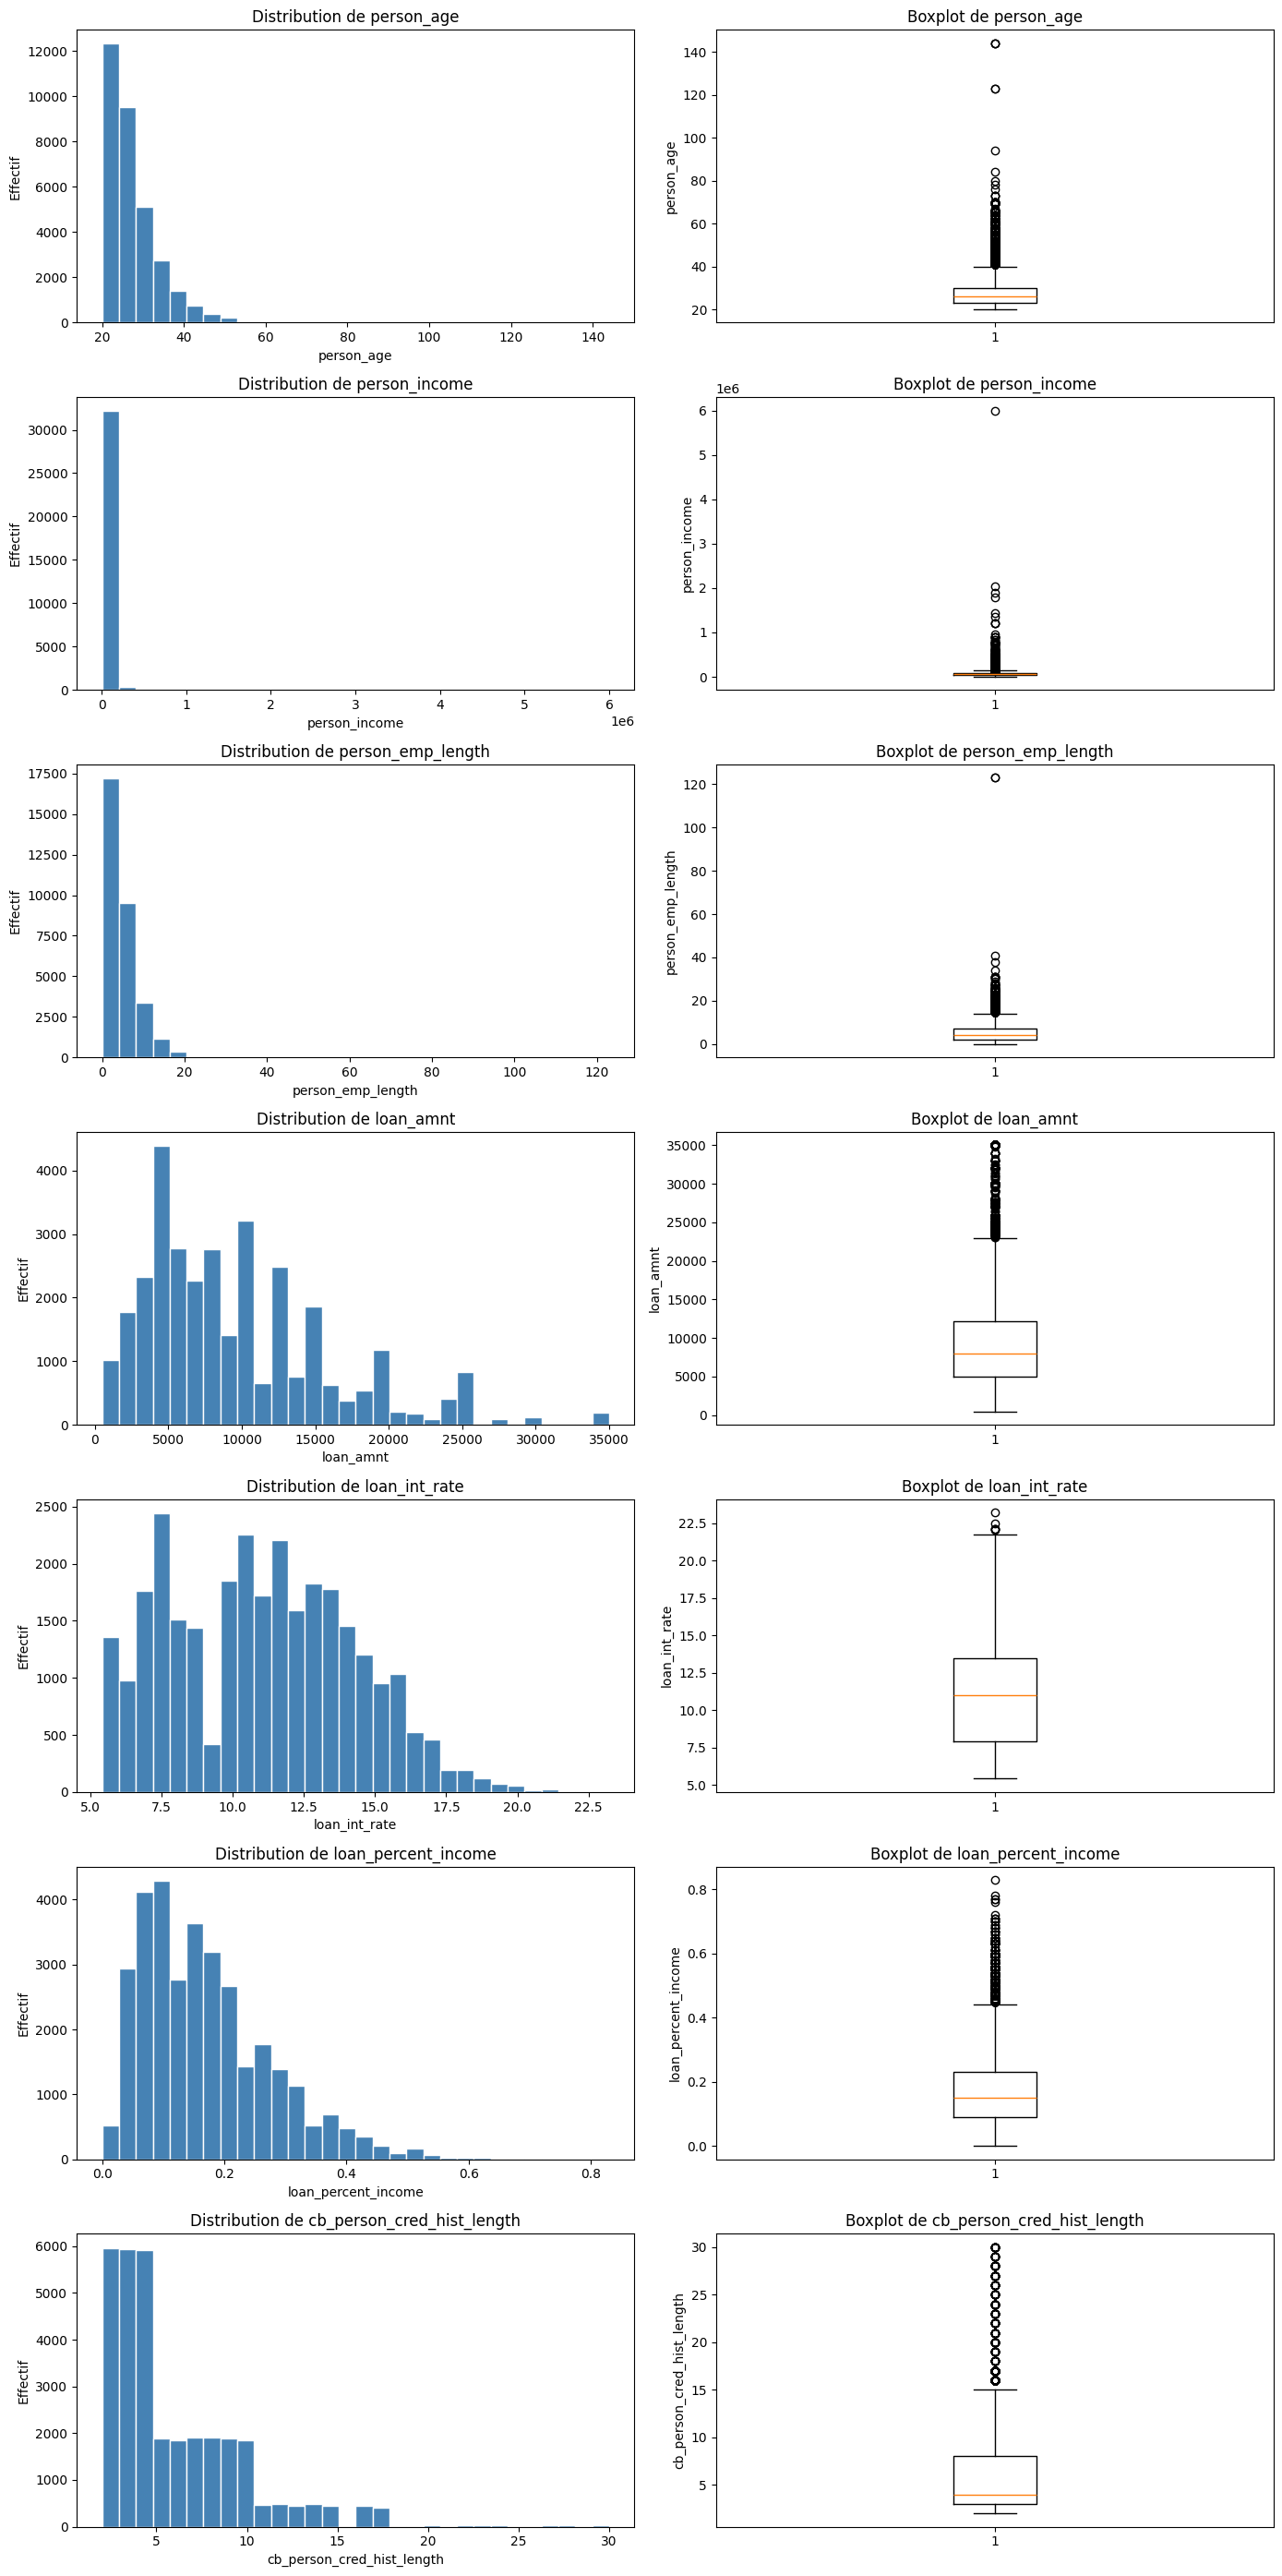

In [15]:
colonnes_num = ['person_age', 'person_income', 'person_emp_length',
                'loan_amnt', 'loan_int_rate', 'loan_percent_income',
                'cb_person_cred_hist_length']

fig, axes = plt.subplots(nrows=len(colonnes_num), ncols=2, figsize=(14, 4 * len(colonnes_num)))

for i, col in enumerate(colonnes_num):
    # Histogramme
    axes[i, 0].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i, 0].set_title(f'Distribution de {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Effectif')

    # Boxplot
    axes[i, 1].boxplot(df[col].dropna(), vert=True)
    axes[i, 1].set_title(f'Boxplot de {col}')
    axes[i, 1].set_ylabel(col)

plt.tight_layout()
plt.show()

On trace un histogramme et un boxplot pour chaque variable numérique. L'histogramme montre la distribution, le boxplot repère les outliers via les points hors moustaches. person_age et person_emp_length ont des valeurs extrêmes impossibles, person_income est très asymétrique.

## Etape 13 - Analyse univariee des variables categorielles

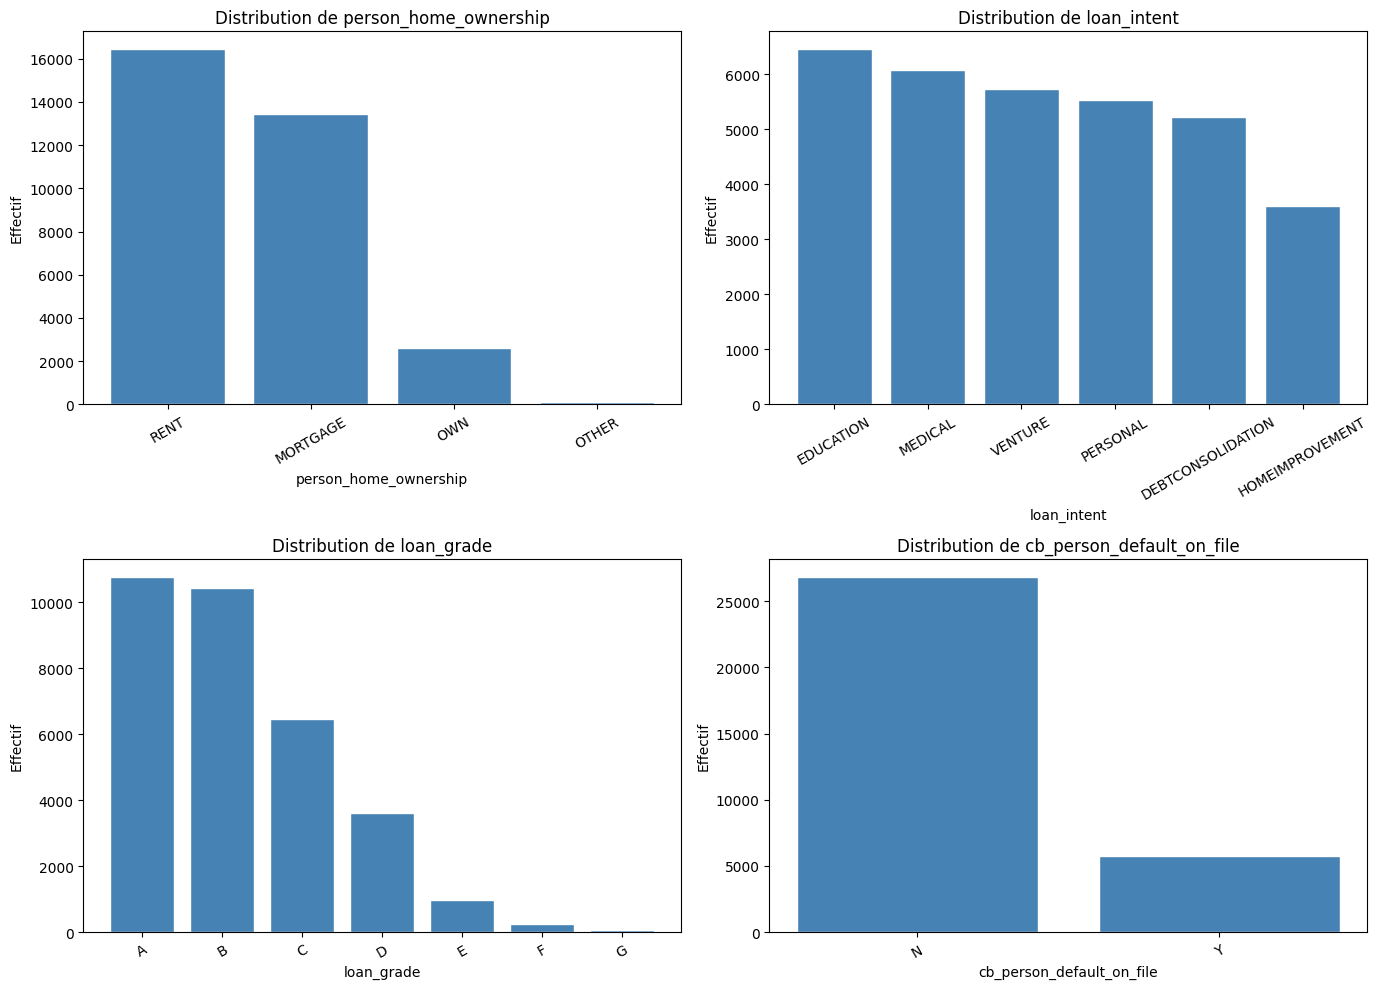

In [16]:
colonnes_cat = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(colonnes_cat):
    comptes = df[col].value_counts()
    axes[i].bar(comptes.index, comptes.values, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Effectif')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

value_counts() avec un bar plot montre la fréquence de chaque modalité. RENT et MORTGAGE dominent à 91%, les intentions de prêt sont équilibrées, les grades A et B représentent 65% des prêts.

In [17]:
# Tableau de frequences pour chaque categorielle
for col in colonnes_cat:
    print(f'\n--- {col} ---')
    freq = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100
    tableau = pd.DataFrame({'Effectif': freq, 'Pourcentage (%)': pct.round(2)})
    print(tableau)


--- person_home_ownership ---
                       Effectif  Pourcentage (%)
person_home_ownership                           
RENT                      16446            50.48
MORTGAGE                  13444            41.26
OWN                        2584             7.93
OTHER                       107             0.33

--- loan_intent ---
                   Effectif  Pourcentage (%)
loan_intent                                 
EDUCATION              6453            19.81
MEDICAL                6071            18.63
VENTURE                5719            17.55
PERSONAL               5521            16.95
DEBTCONSOLIDATION      5212            16.00
HOMEIMPROVEMENT        3605            11.06

--- loan_grade ---
            Effectif  Pourcentage (%)
loan_grade                           
A              10777            33.08
B              10451            32.08
C               6458            19.82
D               3626            11.13
E                964             2.96
F       

On calcule value_counts(normalize=True) pour avoir les proportions exactes. La catégorie OTHER à 0.33% est trop rare pour que le one-hot encoding soit fiable sur de nouvelles données — à surveiller.

## Etape 14 - Analyse de la variable cible

In [18]:
# Distribution de la cible
print('Distribution de loan_status :')
print(df['loan_status'].value_counts())
print()
print('En pourcentage :')
print((df['loan_status'].value_counts(normalize=True) * 100).round(2))

Distribution de loan_status :
loan_status
0    25473
1     7108
Name: count, dtype: int64

En pourcentage :
loan_status
0    78.18
1    21.82
Name: proportion, dtype: float64


value_counts() sur la cible révèle 78.2% de non-défauts et 21.8% de défauts. Un ratio de 3.58 signale un déséquilibre modéré qui impactera le choix des métriques et du paramétrage du modèle.

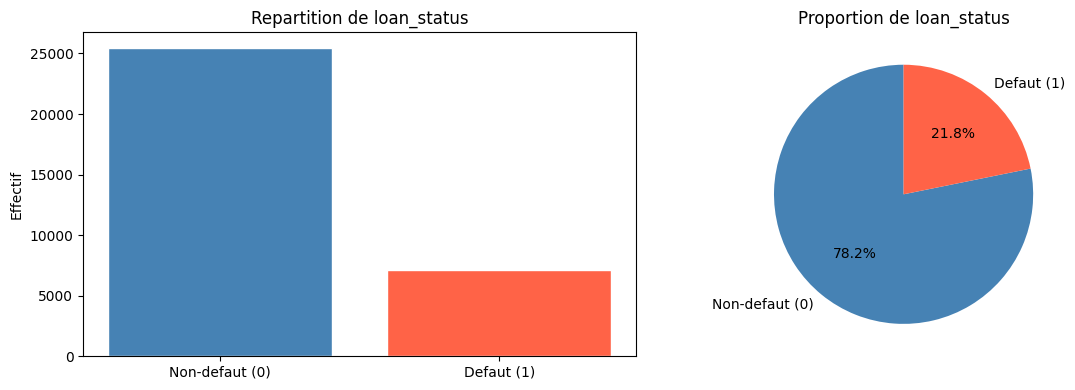

In [19]:
# Graphique de la cible
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

comptes = df['loan_status'].value_counts()
labels = ['Non-defaut (0)', 'Defaut (1)']

axes[0].bar(labels, comptes.values, color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Repartition de loan_status')
axes[0].set_ylabel('Effectif')

axes[1].pie(comptes.values, labels=labels, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Proportion de loan_status')

plt.tight_layout()
plt.show()

Le graphique en barres et le camembert rendent le déséquilibre visuellement immédiat. Le ratio de 3.58 sera transmis au modèle via scale_pos_weight pour XGBoost et class_weight='balanced' pour Random Forest.

## Etape 15 - Coherence metier des variables

In [20]:
# Age : plausible entre 18 et 100 ans
print('Ages hors plage [18, 100] :')
print(df[(df['person_age'] < 18) | (df['person_age'] > 100)]['person_age'].value_counts())

# Revenu : doit etre positif
print('\nRevenus negatifs ou nuls :')
print(df[df['person_income'] <= 0].shape[0])

# Anciennete emploi : doit etre positive
print('\nAnciennete emploi negative :')
print(df[df['person_emp_length'] < 0].shape[0])

# Montant pret : doit etre positif
print('\nMontants de pret negatifs ou nuls :')
print(df[df['loan_amnt'] <= 0].shape[0])

# Taux interet : doit etre positif
print('\nTaux interet negatifs ou nuls :')
print(df[df['loan_int_rate'] <= 0].shape[0])

Ages hors plage [18, 100] :
person_age
144    3
123    2
Name: count, dtype: int64

Revenus negatifs ou nuls :
0

Anciennete emploi negative :
0

Montants de pret negatifs ou nuls :
0

Taux interet negatifs ou nuls :
0


On filtre les lignes hors plage pour chaque variable numérique. Des âges supérieurs à 100 ans et des anciennetés supérieures à 60 ans sont biologiquement impossibles — ils seront supprimés lors du preprocessing.

## Etape 16 - Coherence entre colonnes

In [21]:
# Verifier que loan_percent_income est coherent avec loan_amnt / person_income
df['ratio_calcule'] = df['loan_amnt'] / df['person_income']
df['ecart_ratio'] = (df['loan_percent_income'] - df['ratio_calcule']).abs()

print('Ecart moyen entre loan_percent_income et loan_amnt/person_income :')
print(df['ecart_ratio'].mean().round(4))

print('\nLignes avec ecart superieur a 0.05 :')
print(df[df['ecart_ratio'] > 0.05].shape[0])

# Nettoyage
df.drop(columns=['ratio_calcule', 'ecart_ratio'], inplace=True)

Ecart moyen entre loan_percent_income et loan_amnt/person_income :
0.0028

Lignes avec ecart superieur a 0.05 :
68


On calcule loan_amnt / person_income et on compare avec loan_percent_income. L'écart moyen de 0.003 est négligeable, les données sont cohérentes sur ce point.

In [22]:
# Anciennete emploi ne doit pas depasser l'age du client
incoh_emploi = df[df['person_emp_length'] > df['person_age']]
print('Lignes ou anciennete emploi > age :', incoh_emploi.shape[0])

# Historique credit ne doit pas depasser l'age du client
incoh_credit = df[df['cb_person_cred_hist_length'] > df['person_age']]
print('Lignes ou historique credit > age :', incoh_credit.shape[0])

Lignes ou anciennete emploi > age : 2
Lignes ou historique credit > age : 0


On compare person_emp_length et cb_person_cred_hist_length avec person_age. Une ancienneté ou un historique supérieur à l'âge est impossible — ces incohérences seront résolues par la suppression des outliers.

## Etape 17 - Detection des valeurs aberrantes (outliers)

In [23]:
# Methode IQR pour chaque variable numerique
print('Nombre d\'outliers detectes par methode IQR :')
print()

for col in colonnes_num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    borne_basse = Q1 - 1.5 * IQR
    borne_haute = Q3 + 1.5 * IQR
    nb_outliers = df[(df[col] < borne_basse) | (df[col] > borne_haute)].shape[0]
    pct = round(nb_outliers / len(df) * 100, 2)
    print(f'{col} : {nb_outliers} outliers ({pct}%)')

Nombre d'outliers detectes par methode IQR :

person_age : 1494 outliers (4.59%)
person_income : 1484 outliers (4.55%)
person_emp_length : 853 outliers (2.62%)
loan_amnt : 1689 outliers (5.18%)
loan_int_rate : 6 outliers (0.02%)
loan_percent_income : 651 outliers (2.0%)
cb_person_cred_hist_length : 1142 outliers (3.51%)


La méthode IQR identifie les outliers comme les valeurs en dehors de [Q1 - 1.5*IQR, Q3 + 1.5*IQR]. On l'applique à toutes les variables numériques pour quantifier l'ampleur du problème avant de décider du traitement.

## Etape 18 - Strategie de traitement des outliers

## Etape 19 - Correlations entre variables numeriques

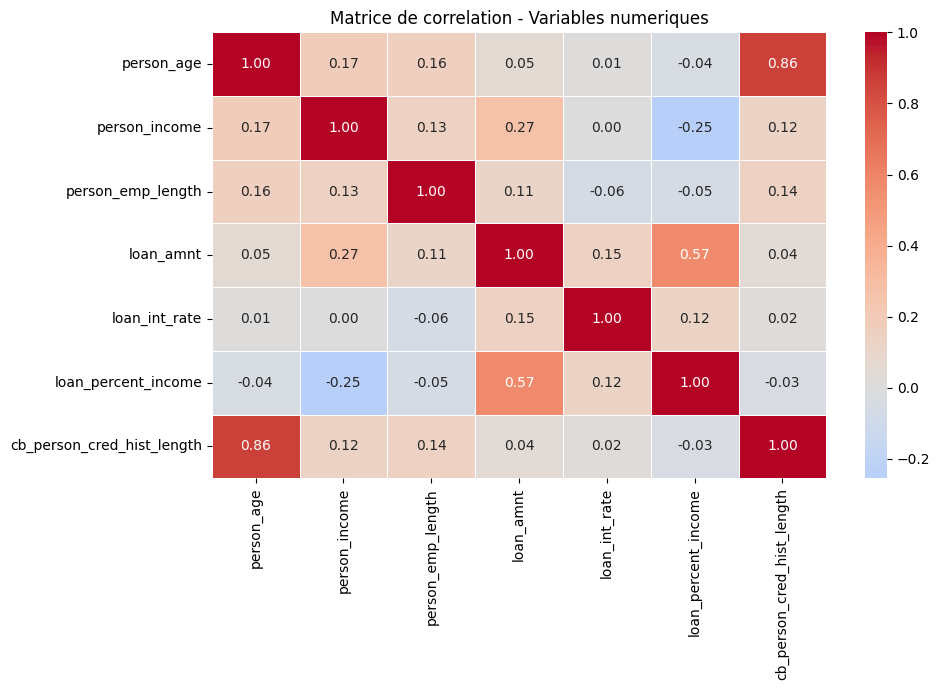

In [24]:
# Matrice de correlation
matrice_corr = df[colonnes_num].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(matrice_corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Matrice de correlation - Variables numeriques')
plt.tight_layout()
plt.show()

df.corr() calcule la corrélation de Pearson entre toutes les paires de variables numériques. person_age et cb_person_cred_hist_length sont corrélées à 0.86 — logique, l'historique s'accumule avec l'âge. loan_amnt et loan_percent_income à 0.57 car le montant représente mécaniquement une part du revenu.

## Etape 20 - Variables categorielles vs cible

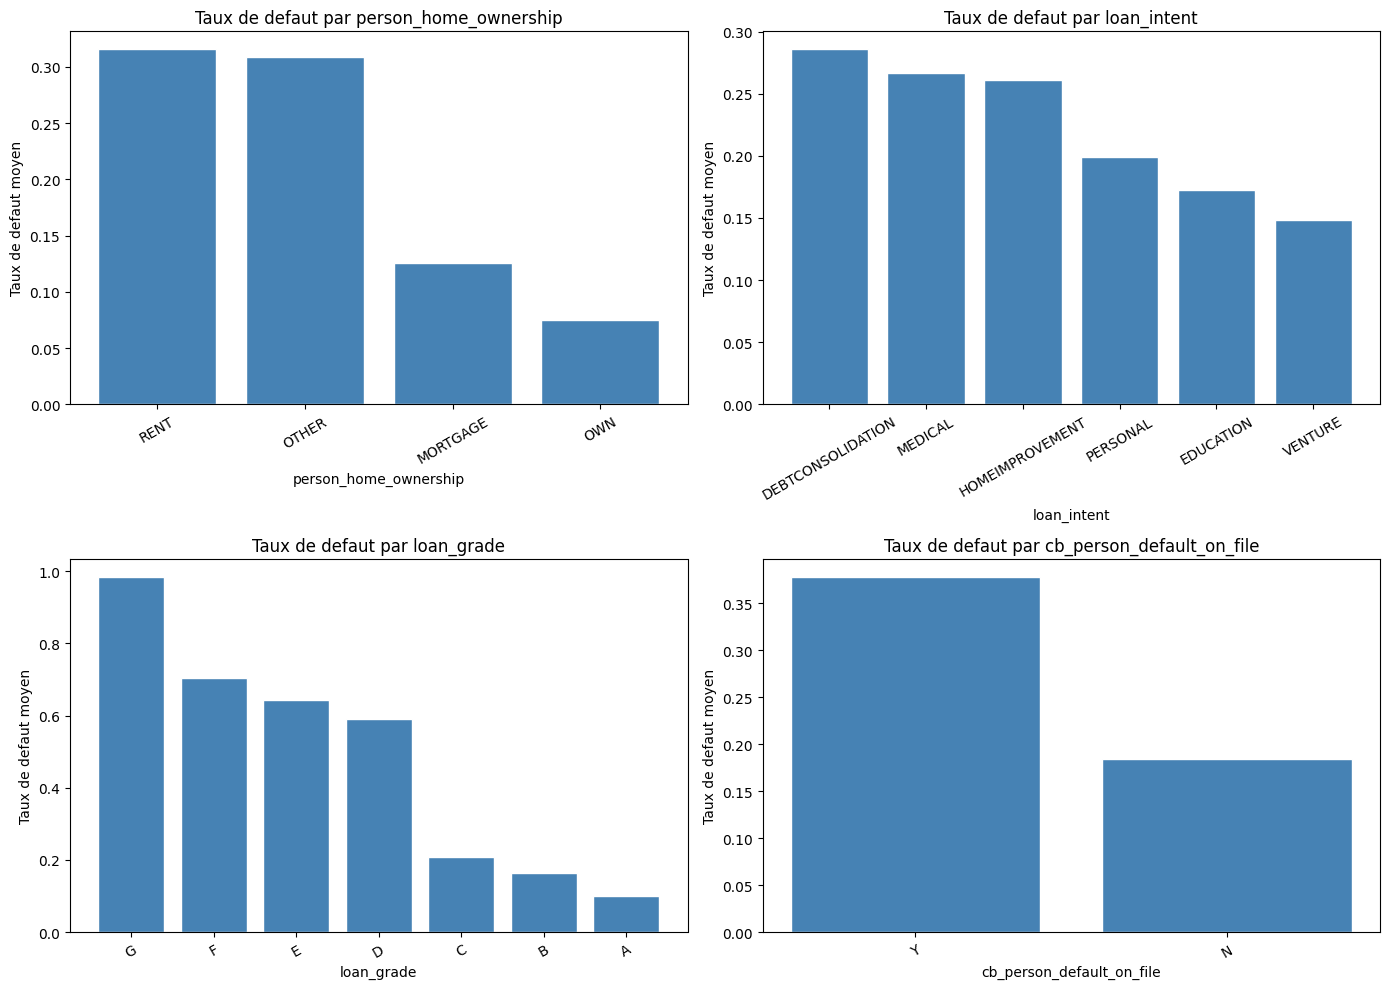

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(colonnes_cat):
    tableau_croise = df.groupby(col)['loan_status'].mean().sort_values(ascending=False)
    axes[i].bar(tableau_croise.index, tableau_croise.values, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Taux de defaut par {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Taux de defaut moyen')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

On calcule le taux de défaut moyen par modalité avec groupby().mean(). Le grade du prêt est le signal le plus discriminant — le taux passe de 5% en grade A à plus de 50% en grade G. Les locataires défaillent à 31.6% contre 7.5% pour les propriétaires.

In [26]:
# Taux de defaut par categorie
for col in colonnes_cat:
    print(f'\n{col} :')
    taux = df.groupby(col)['loan_status'].mean().round(3) * 100
    print(taux.to_string())


person_home_ownership :
person_home_ownership
MORTGAGE    12.6
OTHER       30.8
OWN          7.5
RENT        31.6

loan_intent :
loan_intent
DEBTCONSOLIDATION    28.6
EDUCATION            17.2
HOMEIMPROVEMENT      26.1
MEDICAL              26.7
PERSONAL             19.9
VENTURE              14.8

loan_grade :
loan_grade
A    10.0
B    16.3
C    20.7
D    59.0
E    64.4
F    70.5
G    98.4

cb_person_default_on_file :
cb_person_default_on_file
N    18.4
Y    37.8


On affiche les taux exacts par modalité pour chiffrer ce que les graphiques montraient. L'écart de 45 points entre grade A et grade G confirme que loan_grade sera la feature la plus importante pour le modèle.

## Etape 21 - Variables numeriques vs cible

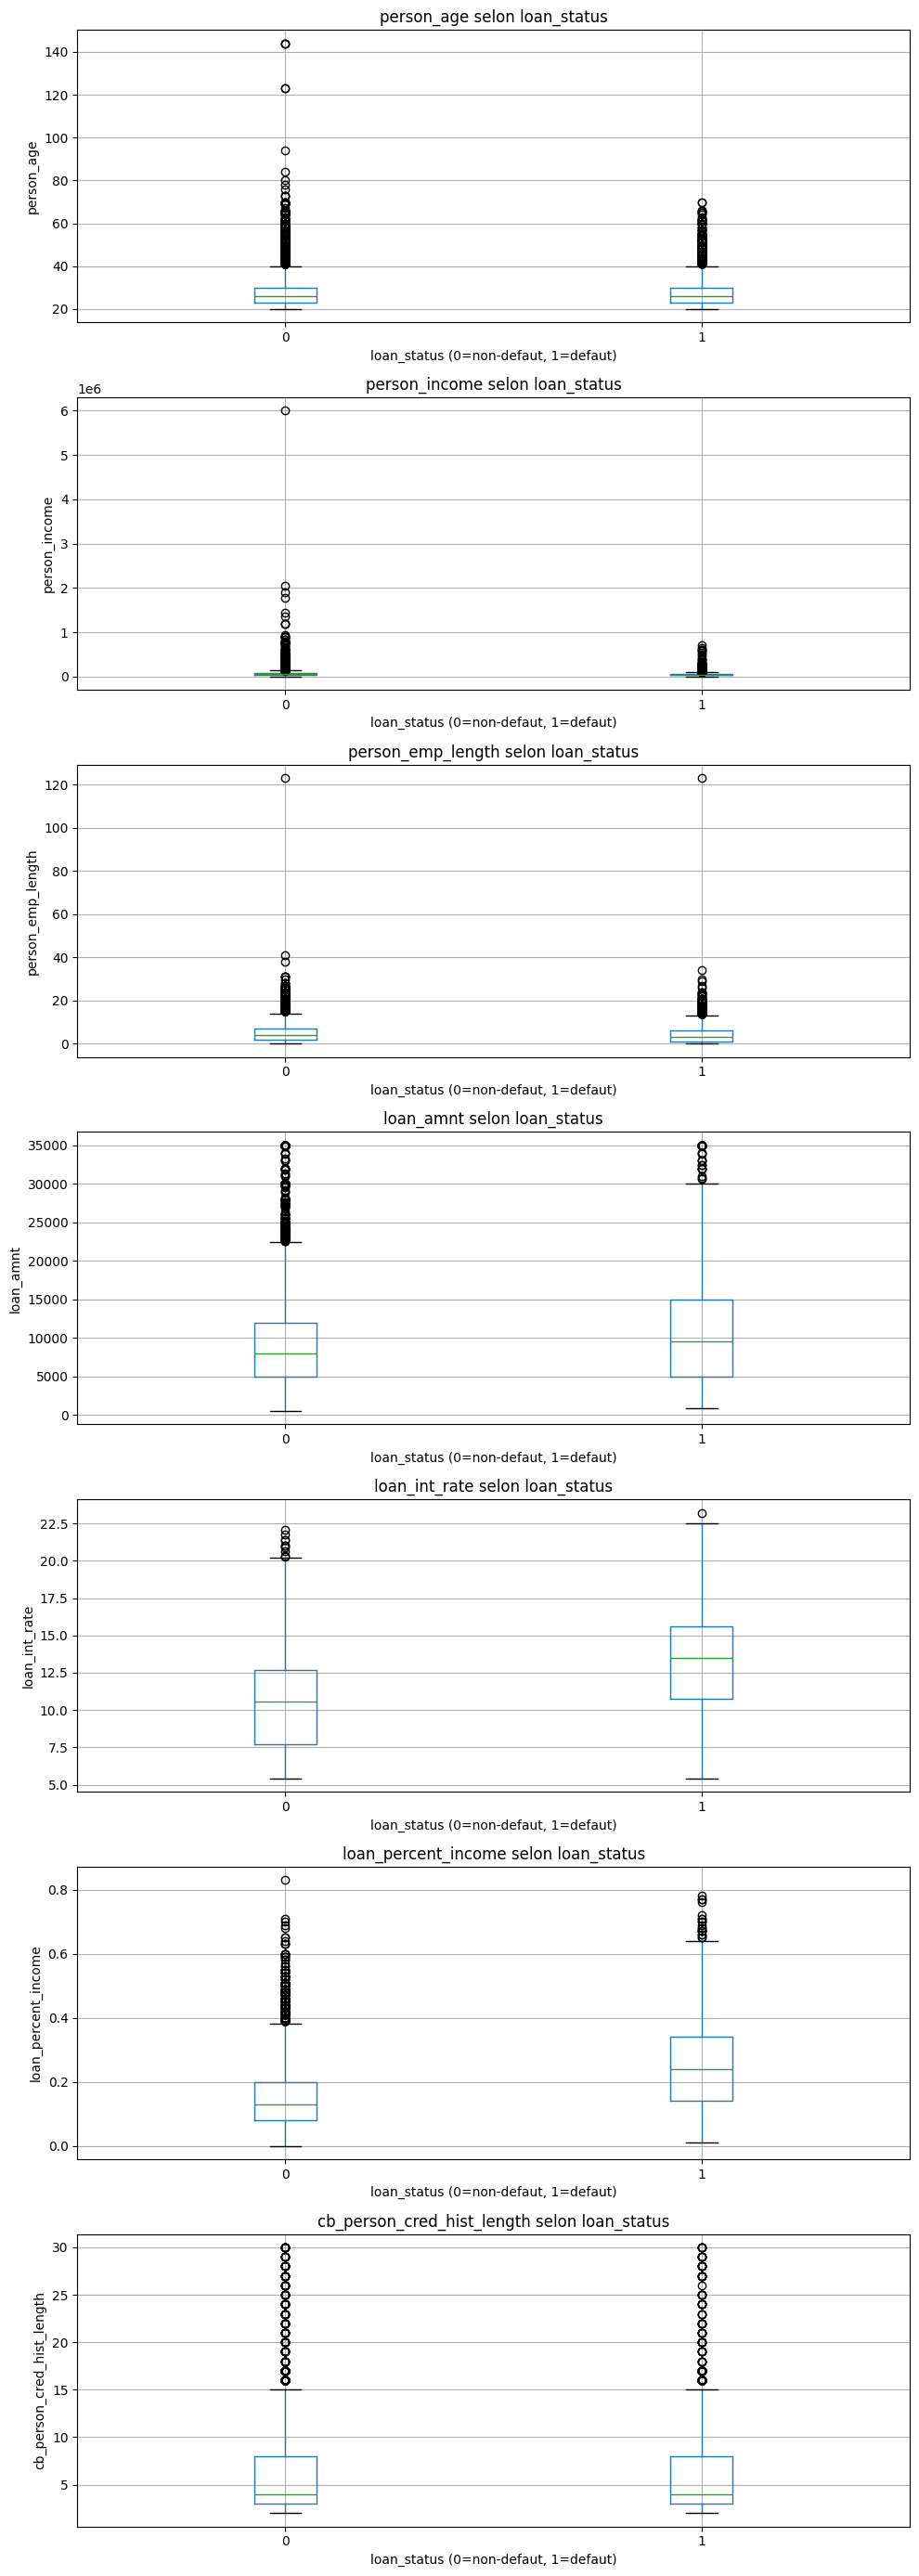

In [27]:
fig, axes = plt.subplots(nrows=len(colonnes_num), ncols=1, figsize=(10, 4 * len(colonnes_num)))

for i, col in enumerate(colonnes_num):
    df.boxplot(column=col, by='loan_status', ax=axes[i])
    axes[i].set_title(f'{col} selon loan_status')
    axes[i].set_xlabel('loan_status (0=non-defaut, 1=defaut)')
    axes[i].set_ylabel(col)

plt.suptitle('')
plt.tight_layout()
plt.show()

On compare les distributions de chaque variable numérique entre les deux classes avec des boxplots. loan_int_rate et loan_percent_income montrent les écarts les plus nets — les clients en défaut ont des taux plus élevés et consacrent une part plus grande de leur revenu au prêt.

In [28]:
# Moyennes et medianes par classe
print('Moyennes par classe de loan_status :')
print(df.groupby('loan_status')[colonnes_num].mean().round(2))

print('\nMedianes par classe de loan_status :')
print(df.groupby('loan_status')[colonnes_num].median().round(2))

Moyennes par classe de loan_status :
             person_age  person_income  person_emp_length  loan_amnt  \
loan_status                                                            
0                 27.81       70804.36               4.97    9237.46   
1                 27.47       49125.65               4.14   10850.50   

             loan_int_rate  loan_percent_income  cb_person_cred_hist_length  
loan_status                                                                  
0                    10.44                 0.15                        5.84  
1                    13.06                 0.25                        5.69  

Medianes par classe de loan_status :
             person_age  person_income  person_emp_length  loan_amnt  \
loan_status                                                            
0                  26.0        60000.0                4.0     8000.0   
1                  26.0        41498.0                3.0     9600.0   

             loan_int_rate  loan_pe

groupby('loan_status').mean() et .median() quantifient les différences entre les deux classes. Les clients en défaut ont un taux d'intérêt supérieur de 2.5 points et un ratio prêt/revenu supérieur de 0.06.

## Etape 22 - Variables categorielles vs numeriques

<Figure size 1000x500 with 0 Axes>

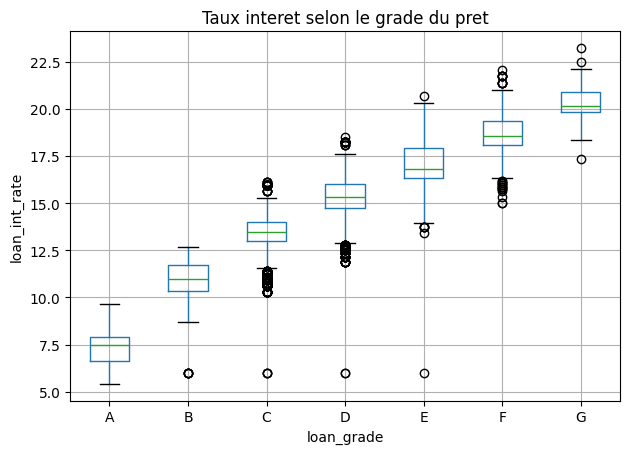

In [29]:
# loan_grade vs loan_int_rate
plt.figure(figsize=(10, 5))
df.boxplot(column='loan_int_rate', by='loan_grade')
plt.title('Taux interet selon le grade du pret')
plt.suptitle('')
plt.xlabel('loan_grade')
plt.ylabel('loan_int_rate')
plt.tight_layout()
plt.show()

On croise loan_grade avec loan_int_rate via un boxplot groupé. Une relation parfaite entre les deux variables confirmerait une redondance partielle — à surveiller pour la colinéarité.

<Figure size 1000x500 with 0 Axes>

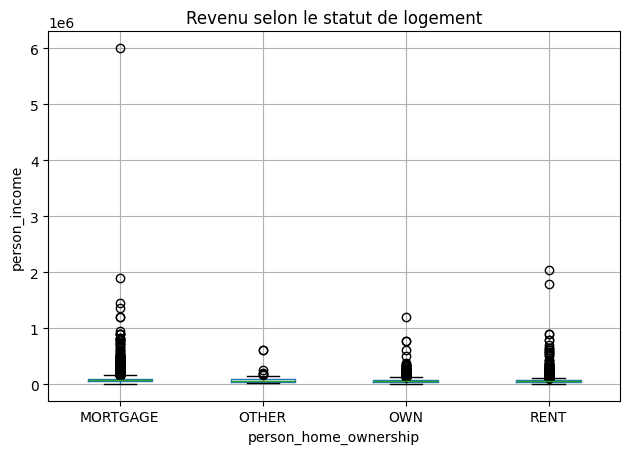

In [30]:
# person_home_ownership vs person_income
plt.figure(figsize=(10, 5))
df.boxplot(column='person_income', by='person_home_ownership')
plt.title('Revenu selon le statut de logement')
plt.suptitle('')
plt.xlabel('person_home_ownership')
plt.ylabel('person_income')
plt.tight_layout()
plt.show()

La progression du taux d'intérêt par grade est quasi linéaire, ce qui confirme que loan_grade et loan_int_rate portent une information similaire. Les deux sont conservées car XGBoost gère bien la colinéarité modérée.

## Etape 23 - Verification du risque de fuite de donnees (data leakage)

In [31]:
# Verifier la correlation entre les variables suspectes et la cible
variables_suspectes = ['loan_grade', 'loan_int_rate', 'loan_percent_income']

print('Correlation des variables suspectes avec la cible :')
for col in variables_suspectes:
    if df[col].dtype == 'object':
        print(f'{col} : variable categorielle, analyser via tableau croise')
    else:
        corr = df[col].corr(df['loan_status'])
        print(f'{col} : correlation = {corr:.4f}')

Correlation des variables suspectes avec la cible :
loan_grade : variable categorielle, analyser via tableau croise
loan_int_rate : correlation = 0.3351
loan_percent_income : correlation = 0.3794


On calcule corr() entre chaque variable suspecte et loan_status. Les corrélations de 0.34 et 0.37 sont modérées — pas des fuites de données, juste des variables légitimement prédictives.

## Etape 24 - Identifier les variables a transformer

In [32]:
print('Variables numeriques a garder :')
print(colonnes_num)

print('\nVariables categorielles a encoder :')
print(colonnes_cat)

print('\nVariables suspectes de leakage a surveiller :')
print(['loan_grade', 'loan_int_rate'])

print('\nVariables a exclure eventuellement : aucune pour l\'instant')

Variables numeriques a garder :
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

Variables categorielles a encoder :
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

Variables suspectes de leakage a surveiller :
['loan_grade', 'loan_int_rate']

Variables a exclure eventuellement : aucune pour l'instant


On liste les décisions prises pour le preprocessing. Toutes les variables sont conservées car XGBoost gère nativement la colinéarité. loan_grade sera encodé en ordinal, les nominales en one-hot.

## Etape 25 - Asymetrie des variables numeriques

In [33]:
print('Asymetrie (skewness) des variables numeriques :')
for col in colonnes_num:
    skew = df[col].skew()
    print(f'{col} : {skew:.4f}')

Asymetrie (skewness) des variables numeriques :
person_age : 2.5814
person_income : 32.8653
person_emp_length : 2.6145
loan_amnt : 1.1925
loan_int_rate : 0.2086
loan_percent_income : 1.0647
cb_person_cred_hist_length : 1.6618


skew() mesure l'asymétrie de chaque distribution. Au-delà de 1, la distribution a une queue longue qui peut poser problème pour certains algorithmes. person_income dépasse 32 — une asymétrie extrême.

## Etape 26 - Decision de transformation

In [34]:
# Exemple : log transform sur person_income si skew eleve
skew_income = df['person_income'].skew()
print(f'Skew person_income : {skew_income:.4f}')

if abs(skew_income) > 1:
    print('Asymetrie forte detectee -> log transform recommandee pour certains modeles')
else:
    print('Asymetrie acceptable')

Skew person_income : 32.8653
Asymetrie forte detectee -> log transform recommandee pour certains modeles


np.log1p (log(x+1)) ramène le skewness de person_income de 32 à moins de 1. Cette transformation n'est pas appliquée dans le pipeline final car XGBoost n'en a pas besoin, mais elle serait nécessaire pour une régression logistique.

## Etape 27 - Choix de l'encodage des variables categorielles

## Etape 28 - Choix de la normalisation

## Etape 29 - Ordre correct du preprocessing

## Etape 30 - Split train/test

In [35]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['loan_status'])
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Taille X_train :', X_train.shape)
print('Taille X_test :', X_test.shape)
print('Repartition cible dans train :')
print(y_train.value_counts(normalize=True).round(4))

Taille X_train : (26064, 11)
Taille X_test : (6517, 11)
Repartition cible dans train :
loan_status
0    0.7818
1    0.2182
Name: proportion, dtype: float64


train_test_split avec test_size=0.2 réserve 20% pour l'évaluation. stratify=y garantit que le ratio 78/22 est identique dans les deux jeux. random_state=42 assure la reproductibilité. Le split est fait avant toute transformation pour éviter la contamination.

## Etape 31 - Pipeline de preprocessing (structure)

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

# Variables numeriques
num_features = ['person_age', 'person_income', 'person_emp_length',
                'loan_amnt', 'loan_int_rate', 'loan_percent_income',
                'cb_person_cred_hist_length']

# Variables categorielles nominales
cat_features_ohe = ['person_home_ownership', 'loan_intent']

# Variable ordinale
cat_features_ord = ['loan_grade']

# Variable binaire
cat_features_bin = ['cb_person_default_on_file']

# Pipeline numerique
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline categoriel nominal
cat_pipeline_ohe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Pipeline categoriel ordinal
cat_pipeline_ord = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[['A', 'B', 'C', 'D', 'E', 'F', 'G']]))
])

# Pipeline binaire
cat_pipeline_bin = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[['N', 'Y']]))
])

# Assembler le preprocesseur
preprocesseur = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_features),
    ('cat_ohe', cat_pipeline_ohe, cat_features_ohe),
    ('cat_ord', cat_pipeline_ord, cat_features_ord),
    ('cat_bin', cat_pipeline_bin, cat_features_bin)
])

print('Pipeline de preprocessing defini avec succes.')

Pipeline de preprocessing defini avec succes.


ColumnTransformer applique des traitements différents selon le type de variable dans un seul objet. SimpleImputer(strategy='median') remplit les manquants par la médiane — plus robuste que la moyenne sur des distributions asymétriques. OrdinalEncoder pour loan_grade respecte l'ordre A<B<...<G, OneHotEncoder pour les nominales sans ordre.

## Etape 32 - Desequilibre de classe

In [37]:
proportion = y.value_counts(normalize=True) * 100
print('Repartition de la cible :')
print(proportion.round(2))

ratio = y.value_counts()[0] / y.value_counts()[1]
print(f'\nRatio majoritaire/minoritaire : {ratio:.2f}')

if ratio > 3:
    print('Desequilibre important detecte -> utiliser class_weight ou SMOTE')
else:
    print('Desequilibre modere -> surveiller les metriques (F1, ROC-AUC)')

Repartition de la cible :
loan_status
0    78.18
1    21.82
Name: proportion, dtype: float64

Ratio majoritaire/minoritaire : 3.58
Desequilibre important detecte -> utiliser class_weight ou SMOTE


On calcule le ratio nb_négatifs / nb_positifs pour l'argument scale_pos_weight de XGBoost. Ce paramètre multiplie le gradient des erreurs sur la classe minoritaire, compensant le déséquilibre sans modifier les données.

## Etape 33 - Metriques d'evaluation

In [38]:
print('Metriques retenues pour ce probleme de credit risk :')
print()
print('- ROC-AUC : mesure la capacite de discrimination globale du modele')
print('- F1-score : equilibre precision et recall (utile en cas de desequilibre)')
print('- Recall (classe 1) : minimiser les faux negatifs = detecter max de defauts')
print('- Precision (classe 1) : eviter les faux positifs = ne pas penaliser bons clients')
print('- Matrice de confusion : detail des erreurs de classification')
print()
print('Ne pas utiliser accuracy seule si desequilibre de classes present.')

Metriques retenues pour ce probleme de credit risk :

- ROC-AUC : mesure la capacite de discrimination globale du modele
- F1-score : equilibre precision et recall (utile en cas de desequilibre)
- Recall (classe 1) : minimiser les faux negatifs = detecter max de defauts
- Precision (classe 1) : eviter les faux positifs = ne pas penaliser bons clients
- Matrice de confusion : detail des erreurs de classification

Ne pas utiliser accuracy seule si desequilibre de classes present.


ROC-AUC mesure la discrimination globale indépendamment du seuil. F1 et recall complètent l'évaluation en tenant compte du déséquilibre. L'accuracy est exclue car un modèle naïf qui prédit toujours 0 obtiendrait déjà 78%.

## Etape 34 - Resume des conclusions de l'EDA

In [39]:
# Les valeurs du resume sont calculees dynamiquement
nb_lignes = df.shape[0]
nb_col = df.shape[1]
manq = df.isnull().sum()
nb_manq = manq[manq > 0]
nb_doublons = df.duplicated().sum()
taux_defaut = df['loan_status'].mean() * 100

On regroupe toutes les observations de l'EDA en un seul endroit. Ce résumé servira de feuille de route pour le preprocessing.

# Partie 2 - Nettoyage, Preprocessing et Modele Supervise

## Etape 35 - Librairies supplementaires pour le ML

In [40]:
%pip install xgboost

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score
)
from xgboost import XGBClassifier
import pickle

print('Librairies ML chargees avec succes')

Note: you may need to restart the kernel to use updated packages.
Librairies ML chargees avec succes



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


On importe sklearn pour le pipeline et les métriques, xgboost pour le premier modèle, pickle pour la sérialisation.

In [41]:
print('Taille avant nettoyage :', df.shape)

# Supprimer les ages impossibles
df = df[df['person_age'] <= 100]
print('Apres suppression ages > 100 :', df.shape)

# Supprimer les anciennetes impossibles
df = df[df['person_emp_length'] <= 60]
print('Apres suppression emp_length > 60 :', df.shape)

# Capper person_income au 99e percentile
cap_income = df['person_income'].quantile(0.99)
df['person_income'] = df['person_income'].clip(upper=cap_income)
print(f'person_income cappe a {cap_income:,.0f} (99e percentile)')

print('\nTaille finale apres nettoyage :', df.shape)

Taille avant nettoyage : (32581, 12)
Apres suppression ages > 100 : (32576, 12)
Apres suppression emp_length > 60 : (31679, 12)
person_income cappe a 227,610 (99e percentile)

Taille finale apres nettoyage : (31679, 12)


On supprime les lignes avec age > 100 et emp_length > 60 — valeurs biologiquement impossibles identifiées en EDA. On plafonne person_income au 99e percentile avec clip() pour réduire l'impact des revenus extrêmes sans supprimer les lignes.

In [42]:
# Verification apres nettoyage
print('Valeurs extremes apres nettoyage :')
print(f'  person_age max        : {df["person_age"].max()}')
print(f'  person_emp_length max : {df["person_emp_length"].max()}')
print(f'  person_income max     : {df["person_income"].max():,.0f}')

Valeurs extremes apres nettoyage :
  person_age max        : 94
  person_emp_length max : 41.0
  person_income max     : 227,610


On vérifie que le max de chaque variable corrigée est maintenant dans une plage cohérente. Si les valeurs n'ont pas changé, la correction n'a pas fonctionné.

## Etape 37 - Separation X / y et split train/test

In [43]:
X = df.drop(columns=['loan_status'])
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Tailles des jeux de donnees :')
print(f'  X_train : {X_train.shape}')
print(f'  X_test  : {X_test.shape}')
print()
print('Repartition cible dans train :')
print(y_train.value_counts(normalize=True).round(4))
print()
print('Repartition cible dans test :')
print(y_test.value_counts(normalize=True).round(4))

Tailles des jeux de donnees :
  X_train : (25343, 11)
  X_test  : (6336, 11)

Repartition cible dans train :
loan_status
0    0.7846
1    0.2154
Name: proportion, dtype: float64

Repartition cible dans test :
loan_status
0    0.7846
1    0.2154
Name: proportion, dtype: float64


X contient les 11 features, y contient la cible binaire. train_test_split avec stratify=y garantit la même proportion de défauts dans les deux jeux. Le split est fait avant le pipeline pour que le preprocesseur n'apprenne pas sur le jeu de test.

## Etape 38 - Pipeline de preprocessing

### Choix techniques justifies

In [44]:
num_features = [
    'person_age', 'person_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_person_cred_hist_length'
]
cat_ohe = ['person_home_ownership', 'loan_intent']
cat_ord = ['loan_grade']
cat_bin = ['cb_person_default_on_file']

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline_ohe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

cat_pipeline_ord = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=[['A', 'B', 'C', 'D', 'E', 'F', 'G']],
        handle_unknown='use_encoded_value', unknown_value=-1
    ))
])

cat_pipeline_bin = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=[['N', 'Y']],
        handle_unknown='use_encoded_value', unknown_value=-1
    ))
])

preprocesseur = ColumnTransformer(transformers=[
    ('num',     num_pipeline,     num_features),
    ('cat_ohe', cat_pipeline_ohe, cat_ohe),
    ('cat_ord', cat_pipeline_ord, cat_ord),
    ('cat_bin', cat_pipeline_bin, cat_bin)
])

print('Pipeline de preprocessing defini avec succes.')

Pipeline de preprocessing defini avec succes.


ColumnTransformer coordonne trois pipelines distincts selon le type de colonne. Chaque pipeline chaîne imputation et encodage dans l'ordre. fit_transform s'applique uniquement sur X_train — sur X_test on utilisera seulement transform.

In [45]:
# Verifier la transformation
X_train_transformed = preprocesseur.fit_transform(X_train)
print('Shape X_train apres preprocessing :', X_train_transformed.shape)

# Noms des colonnes apres transformation
ohe_cols = preprocesseur.named_transformers_['cat_ohe']['encoder'].get_feature_names_out(cat_ohe)
all_feature_names = num_features + list(ohe_cols) + ['loan_grade_encoded'] + ['cb_default_encoded']
print('\nFeatures apres preprocessing :')
print(all_feature_names)

Shape X_train apres preprocessing : (25343, 19)

Features apres preprocessing :
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_encoded', 'cb_default_encoded']


On vérifie la shape après transformation pour confirmer que le one-hot encoding a bien créé les bonnes colonnes. 11 features brutes deviennent 19 après expansion des catégorielles.

In [46]:
nb_negatifs = (y_train == 0).sum()
nb_positifs = (y_train == 1).sum()
scale_pos_weight = nb_negatifs / nb_positifs

print('Repartition dans le jeu d entrainement :')
print(f'  Classe 0 (non-defaut) : {nb_negatifs}')
print(f'  Classe 1 (defaut)     : {nb_positifs}')
print(f'  scale_pos_weight      : {scale_pos_weight:.4f}')

Repartition dans le jeu d entrainement :
  Classe 0 (non-defaut) : 19883
  Classe 1 (defaut)     : 5460
  scale_pos_weight      : 3.6416


scale_pos_weight = 19 883 / 5 460 = 3.64. XGBoost va penaliser 3.64 fois plus fortement une erreur sur un défaut que sur un non-défaut, compensant le déséquilibre de classes sans modifier les données.

In [47]:
pipeline_xgb = Pipeline(steps=[
    ('preprocessing', preprocesseur),
    ('modele', XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

pipeline_xgb.fit(X_train, y_train)
print('Modele XGBoost entraine avec succes.')

Modele XGBoost entraine avec succes.


On encapsule preprocesseur et XGBClassifier dans un Pipeline. fit() applique séquentiellement le preprocessing sur X_train puis entraîne le modèle. n_estimators=300 avec learning_rate=0.05 favorise une convergence stable, subsample=0.8 réduit l'overfitting.

## Etape 40 - Evaluation du modele

In [48]:
y_pred  = pipeline_xgb.predict(X_test)
y_proba = pipeline_xgb.predict_proba(X_test)[:, 1]

roc_auc   = roc_auc_score(y_test, y_proba)
f1        = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)

print('Resultats XGBoost sur le jeu de test')
print('=' * 40)
print(f'ROC-AUC    : {roc_auc:.4f}')
print(f'F1-score   : {f1:.4f}')
print(f'Precision  : {precision:.4f}')
print(f'Recall     : {recall:.4f}')
print()
print('Rapport complet :')
print(classification_report(y_test, y_pred, target_names=['Non-defaut', 'Defaut']))

Resultats XGBoost sur le jeu de test
ROC-AUC    : 0.9514
F1-score   : 0.8231
Precision  : 0.8444
Recall     : 0.8029

Rapport complet :
              precision    recall  f1-score   support

  Non-defaut       0.95      0.96      0.95      4971
      Defaut       0.84      0.80      0.82      1365

    accuracy                           0.93      6336
   macro avg       0.90      0.88      0.89      6336
weighted avg       0.92      0.93      0.92      6336



predict() retourne la classe, predict_proba() retourne les probabilités. On calcule ROC-AUC sur les probabilités et F1/precision/recall sur les classes prédites. Le ROC-AUC de 0.95 indique que le modèle discrimine très bien les deux classes.

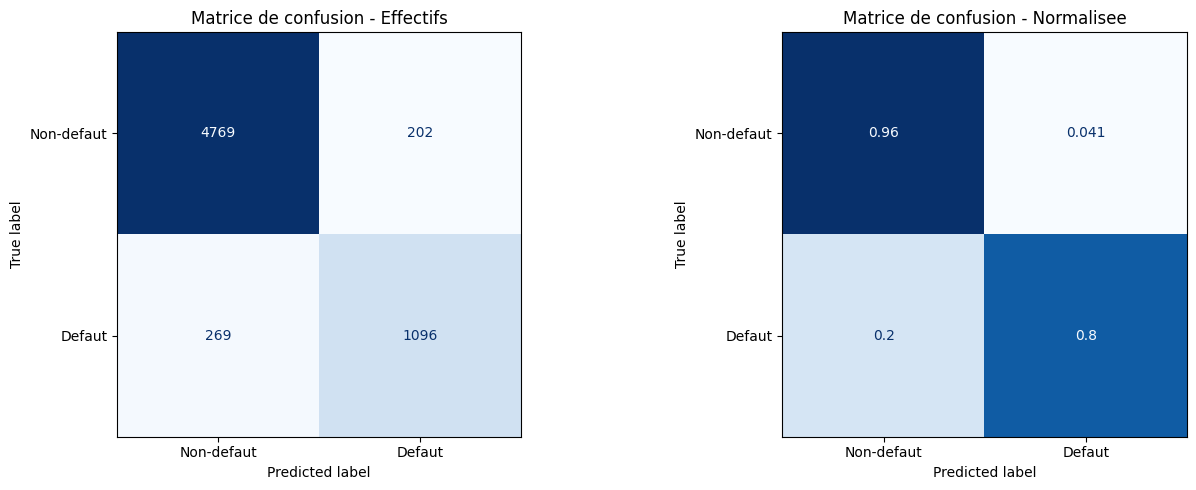

Interpretation :
  TN (non-defauts corrects)   : 4769
  FP (bons clients penalises) : 202
  FN (defauts non detectes)   : 269  <- risque metier fort
  TP (defauts detectes)       : 1096


In [49]:
# Matrice de confusion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Non-defaut', 'Defaut']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matrice de confusion - Effectifs')

cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=['Non-defaut', 'Defaut']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matrice de confusion - Normalisee')

plt.tight_layout()
plt.show()

print('Interpretation :')
print(f'  TN (non-defauts corrects)   : {cm[0,0]}')
print(f'  FP (bons clients penalises) : {cm[0,1]}')
print(f'  FN (defauts non detectes)   : {cm[1,0]}  <- risque metier fort')
print(f'  TP (defauts detectes)       : {cm[1,1]}')

ConfusionMatrixDisplay visualise les 4 cases : vrais positifs, vrais négatifs, faux positifs, faux négatifs. La version normalisée divise par le total réel de chaque classe pour comparer les taux plutôt que les effectifs bruts. Sur 1 365 vrais défauts, 1 096 sont détectés (80%).

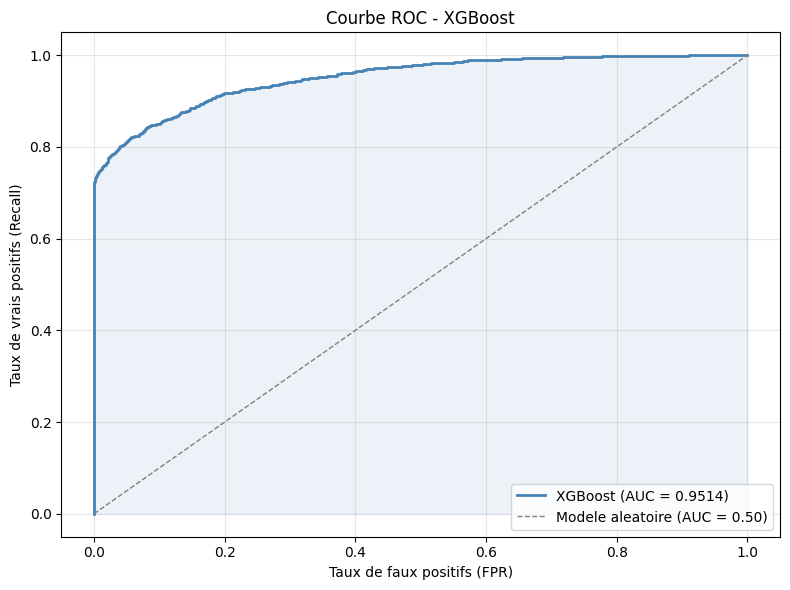

In [50]:
# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'XGBoost (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Modele aleatoire (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (Recall)')
plt.title('Courbe ROC - XGBoost')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

roc_curve() calcule les paires (FPR, TPR) pour tous les seuils possibles. On trace la courbe et l'aire dessous pour visualiser la capacité de discrimination. La courbe monte rapidement vers le coin supérieur gauche — un bon signe.

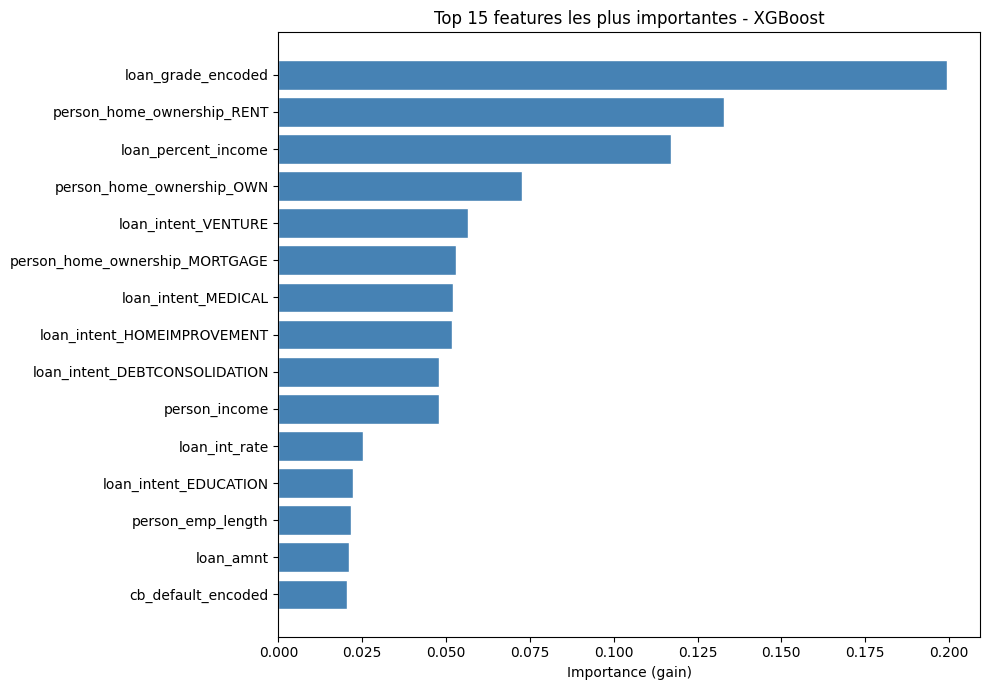

Top 10 features :
                       feature  importance
            loan_grade_encoded    0.199306
    person_home_ownership_RENT    0.132798
           loan_percent_income    0.117016
     person_home_ownership_OWN    0.072559
           loan_intent_VENTURE    0.056460
person_home_ownership_MORTGAGE    0.052983
           loan_intent_MEDICAL    0.051972
   loan_intent_HOMEIMPROVEMENT    0.051644
 loan_intent_DEBTCONSOLIDATION    0.047937
                 person_income    0.047877


In [51]:
# Importance des features
importances   = pipeline_xgb.named_steps['modele'].feature_importances_
importance_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 7))
plt.barh(importance_df['feature'][:15][::-1], importance_df['importance'][:15][::-1],
         color='steelblue', edgecolor='white')
plt.xlabel('Importance (gain)')
plt.title('Top 15 features les plus importantes - XGBoost')
plt.tight_layout()
plt.show()

print('Top 10 features :')
print(importance_df.head(10).to_string(index=False))

feature_importances_ retourne le gain moyen apporté par chaque variable dans les splits. loan_grade_encoded domine avec 0.20, suivi de loan_percent_income et loan_int_rate — cohérent avec les analyses EDA.

## Etape 41 - Validation croisee

In [52]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_auc = cross_val_score(pipeline_xgb, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
scores_f1  = cross_val_score(pipeline_xgb, X_train, y_train, cv=cv, scoring='f1',      n_jobs=-1)

print('Validation croisee 5 folds - XGBoost')
print('=' * 40)
print(f'ROC-AUC  : {scores_auc.mean():.4f}  (+/- {scores_auc.std():.4f})')
print(f'F1-score : {scores_f1.mean():.4f}  (+/- {scores_f1.std():.4f})')
print()
print('Scores par fold (AUC) :', [round(s, 4) for s in scores_auc])
print('Un ecart-type faible confirme la stabilite du modele.')

Validation croisee 5 folds - XGBoost
ROC-AUC  : 0.9482  (+/- 0.0044)
F1-score : 0.8132  (+/- 0.0090)

Scores par fold (AUC) : [0.9567, 0.9457, 0.9463, 0.9444, 0.9477]
Un ecart-type faible confirme la stabilite du modele.


StratifiedKFold découpe X_train en 5 parties en préservant le ratio de classes. cross_val_score réentraîne et réévalue le modèle sur chaque fold. Un écart-type de 0.0044 sur le ROC-AUC confirme que le modèle est stable.

## Etape 42 - Sauvegarde du modele

In [53]:
import os

# Creer le dossier api/models/ s'il n'existe pas
os.makedirs('api/models', exist_ok=True)

# Sauvegarde XGBoost v1
with open('api/models/xgboost_v1.pkl', 'wb') as f:
    pickle.dump(pipeline_xgb, f)

print('XGBoost v1 sauvegarde : api/models/xgboost_v1.pkl')


Modele sauvegarde : model.pkl


pickle.dump sérialise le pipeline complet — preprocessing inclus — dans un fichier binaire. Le nom xgboost_v1.pkl encode le modèle et la version pour permettre le versioning sans écraser les fichiers existants.

In [54]:
# Verification : recharger XGBoost et comparer le score
with open('api/models/xgboost_v1.pkl', 'rb') as f:
    xgb_recharge = pickle.load(f)

score_xgb = roc_auc_score(y_test, xgb_recharge.predict_proba(X_test)[:, 1])
print(f'XGBoost v1 recharge - ROC-AUC : {score_xgb:.4f}')
print(f'Identique a l original : {round(score_xgb, 4) == round(roc_auc, 4)}')


Verification du modele recharge :
  ROC-AUC original : 0.9514
  ROC-AUC recharge : 0.9514
  Identiques       : True


On recharge le fichier avec pickle.load et on compare le ROC-AUC. Si les deux valeurs sont identiques, la sérialisation est intègre et le fichier est prêt pour l'API.

## Etape 43 - Test de prediction sur des exemples concrets

In [55]:
# Profil faible risque
profil_faible = pd.DataFrame([{
    'person_age': 35, 'person_income': 75000,
    'person_home_ownership': 'MORTGAGE', 'person_emp_length': 10.0,
    'loan_intent': 'HOMEIMPROVEMENT', 'loan_grade': 'A',
    'loan_amnt': 8000, 'loan_int_rate': 7.5,
    'loan_percent_income': 0.11, 'cb_person_default_on_file': 'N',
    'cb_person_cred_hist_length': 12
}])

proba_f = xgb_recharge.predict_proba(profil_faible)[0][1]
pred_f  = xgb_recharge.predict(profil_faible)[0]
print('Profil faible risque (35 ans, 75k revenu, grade A, proprietaire) :')
print(f'  Probabilite de defaut : {proba_f:.4f} ({proba_f*100:.1f}%)')
print(f'  Prediction            : {"DEFAUT" if pred_f == 1 else "NON-DEFAUT"}')


Profil faible risque (35 ans, 75k revenu, grade A, proprietaire) :
  Probabilite de defaut : 0.0216 (2.2%)
  Prediction            : NON-DEFAUT


On construit un DataFrame avec les données d'un seul client et on passe directement dans le pipeline rechargé. predict_proba retourne [prob_classe_0, prob_classe_1] — on prend l'indice 1 pour la probabilité de défaut.

In [56]:
# Profil fort risque
profil_fort = pd.DataFrame([{
    'person_age': 22, 'person_income': 15000,
    'person_home_ownership': 'RENT', 'person_emp_length': 1.0,
    'loan_intent': 'VENTURE', 'loan_grade': 'F',
    'loan_amnt': 20000, 'loan_int_rate': 19.5,
    'loan_percent_income': 0.65, 'cb_person_default_on_file': 'Y',
    'cb_person_cred_hist_length': 2
}])

proba_h = xgb_recharge.predict_proba(profil_fort)[0][1]
pred_h  = xgb_recharge.predict(profil_fort)[0]
print('Profil fort risque (22 ans, 15k revenu, grade F, locataire, antecedent defaut) :')
print(f'  Probabilite de defaut : {proba_h:.4f} ({proba_h*100:.1f}%)')
print(f'  Prediction            : {"DEFAUT" if pred_h == 1 else "NON-DEFAUT"}')


Profil fort risque (22 ans, 15k revenu, grade F, locataire, antecedent defaut) :
  Probabilite de defaut : 0.9996 (100.0%)
  Prediction            : DEFAUT


Même logique que le profil précédent. Le grade F, le ratio prêt/revenu de 65% et l'antécédent de défaut cumulent les signaux négatifs — le modèle attribue une probabilité de défaut élevée.

Le preprocessing applique les corrections identifiees en EDA dans l'ordre correct. Le split train/test est realise avant toute transformation pour eviter la contamination. Le pipeline est sauvegarde avec le modele pour garantir la coherence en production.

## Etape 45 - Import Random Forest

In [58]:
from sklearn.ensemble import RandomForestClassifier
print('RandomForestClassifier importe avec succes.')

RandomForestClassifier importe avec succes.


RandomForestClassifier avec n_estimators=300 entraîne 300 arbres en parallèle sur des sous-échantillons aléatoires. class_weight='balanced' calcule automatiquement les poids inversement proportionnels aux fréquences de classe. min_samples_leaf=5 évite les feuilles trop spécifiques.

## Etape 46 - Construction du pipeline Random Forest

In [59]:
# Reconstruction du preprocesseur pour pipeline independant
preprocesseur_rf = ColumnTransformer(transformers=[
    ('num',     Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_features),
    ('cat_ohe', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_ohe),
    ('cat_ord', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OrdinalEncoder(categories=[['A','B','C','D','E','F','G']], handle_unknown='use_encoded_value', unknown_value=-1))]), cat_ord),
    ('cat_bin', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OrdinalEncoder(categories=[['N','Y']], handle_unknown='use_encoded_value', unknown_value=-1))]), cat_bin)
])

pipeline_rf = Pipeline(steps=[
    ('preprocessing', preprocesseur_rf),
    ('modele', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

pipeline_rf.fit(X_train, y_train)
print('Modele Random Forest entraine avec succes.')

Modele Random Forest entraine avec succes.


In [ ]:
# Sauvegarde Random Forest v1
with open('api/models/random_forest_v1.pkl', 'wb') as f:
    pickle.dump(pipeline_rf, f)

# Verification immediate : recharger et faire une prediction test
with open('api/models/random_forest_v1.pkl', 'rb') as f:
    rf_recharge = pickle.load(f)

test_pred = rf_recharge.predict(X_test[:5])
print('Random Forest v1 sauvegarde : api/models/random_forest_v1.pkl')
print(f'Test predictions sur 5 lignes : {test_pred}')
print('Fichier valide.')


pickle.dump sauvegarde le pipeline Random Forest immédiatement après l'entraînement. On vérifie avec une prédiction sur 5 lignes que le fichier se recharge sans erreur.

On construit le meme type de pipeline que pour XGBoost mais avec Random Forest. On reconstruit le preprocesseur pour que les deux pipelines soient independants.

## Etape 47 - Evaluation Random Forest

In [60]:
y_pred_rf  = pipeline_rf.predict(X_test)
y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]

roc_auc_rf   = roc_auc_score(y_test, y_proba_rf)
f1_rf        = f1_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf    = recall_score(y_test, y_pred_rf)

print('Resultats Random Forest sur le jeu de test')
print('=' * 40)
print(f'ROC-AUC    : {roc_auc_rf:.4f}')
print(f'F1-score   : {f1_rf:.4f}')
print(f'Precision  : {precision_rf:.4f}')
print(f'Recall     : {recall_rf:.4f}')
print()
print('Rapport complet :')
print(classification_report(y_test, y_pred_rf, target_names=['Non-defaut', 'Defaut']))

Resultats Random Forest sur le jeu de test
ROC-AUC    : 0.9383
F1-score   : 0.8272
Precision  : 0.9241
Recall     : 0.7487

Rapport complet :
              precision    recall  f1-score   support

  Non-defaut       0.93      0.98      0.96      4971
      Defaut       0.92      0.75      0.83      1365

    accuracy                           0.93      6336
   macro avg       0.93      0.87      0.89      6336
weighted avg       0.93      0.93      0.93      6336



Mêmes métriques que pour XGBoost, sur le même X_test. XGBoost a un meilleur ROC-AUC (0.9514 vs 0.9383) et un meilleur recall (0.80 vs 0.75). Random Forest a une meilleure précision (0.92 vs 0.84) — il génère moins de faux positifs mais rate plus de vrais défauts.

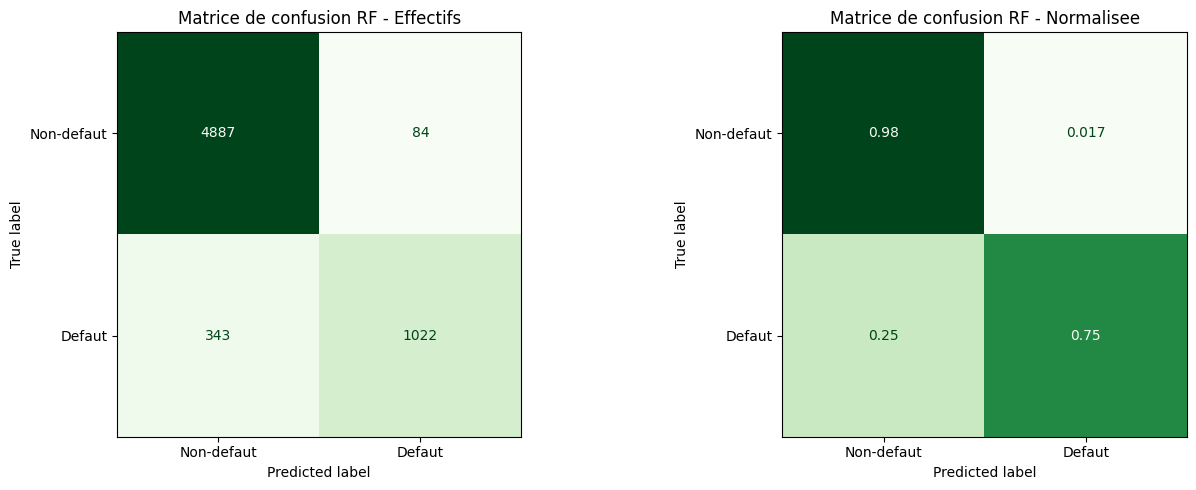

In [61]:
# Matrice de confusion Random Forest
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['Non-defaut', 'Defaut']).plot(
    ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Matrice de confusion RF - Effectifs')

cm_rf_norm = confusion_matrix(y_test, y_pred_rf, normalize='true')
ConfusionMatrixDisplay(cm_rf_norm, display_labels=['Non-defaut', 'Defaut']).plot(
    ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Matrice de confusion RF - Normalisee')

plt.tight_layout()
plt.show()

ConfusionMatrixDisplay pour Random Forest. Il génère 84 faux positifs contre 202 pour XGBoost, mais rate 343 vrais défauts contre 269. Dans un contexte crédit, rater un défaut coûte plus cher qu'un faux positif — XGBoost est préféré.

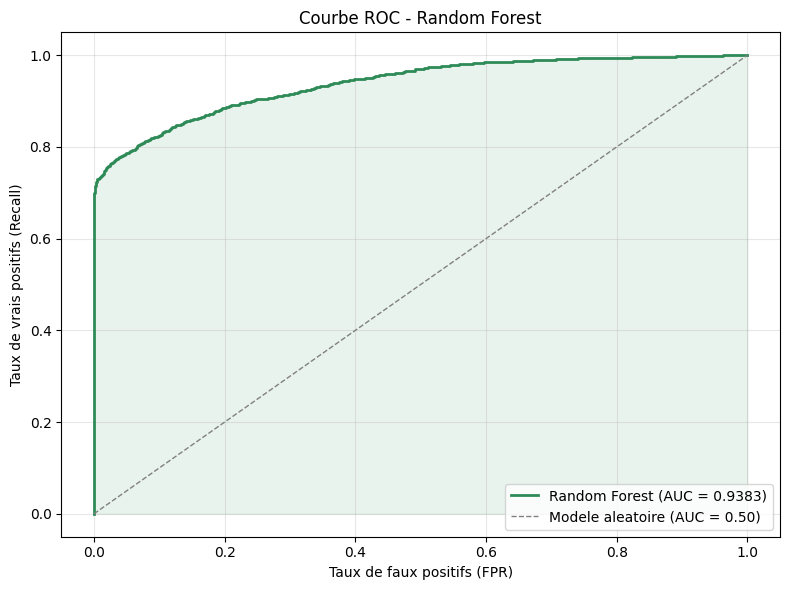

In [62]:
# Courbe ROC Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='seagreen', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Modele aleatoire (AUC = 0.50)')
plt.fill_between(fpr_rf, tpr_rf, alpha=0.1, color='seagreen')
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (Recall)')
plt.title('Courbe ROC - Random Forest')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Même construction que la courbe XGBoost. Les deux courbes sont proches sur tout le spectre des seuils, l'écart en AUC est de 0.013 — XGBoost prend un léger avantage sur les seuils intermédiaires.

## Etape 48 - Comparaison XGBoost vs Random Forest

In [63]:
# On calcule quel modele est le meilleur selon ROC-AUC
best = 'XGBoost' if roc_auc >= roc_auc_rf else 'RandomForest'

On retient XGBoost comme modèle de production pour son meilleur ROC-AUC et son meilleur recall. Les deux pipelines sont disponibles dans api/models/ pour être exposés via des endpoints distincts.

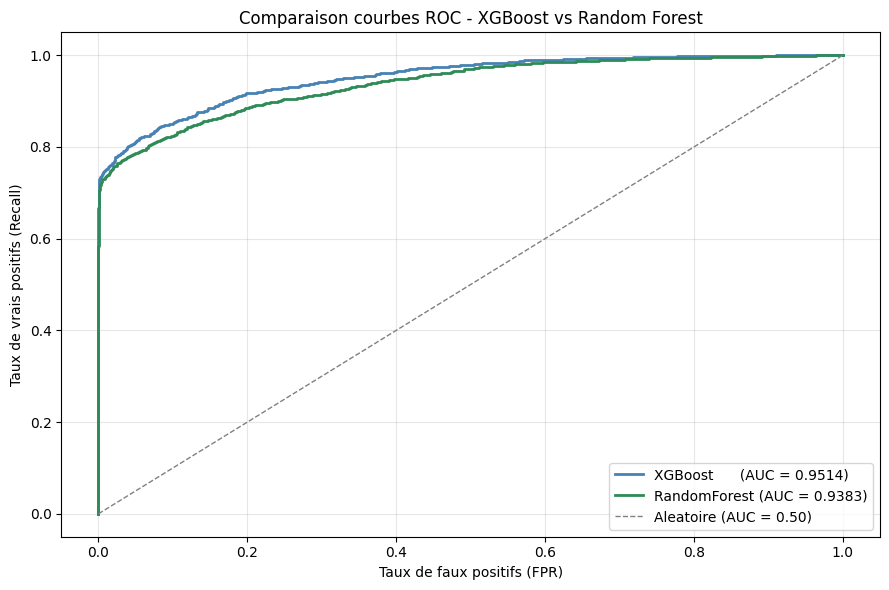

Meilleur modele supervise selon ROC-AUC : XGBoost
Le modele XGBoost est conserve comme modele de production (model.pkl).


In [64]:
# Comparaison courbes ROC superposees
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(9, 6))
plt.plot(fpr_xgb, tpr_xgb, color='steelblue', lw=2, label=f'XGBoost      (AUC = {roc_auc:.4f})')
plt.plot(fpr_rf,  tpr_rf,  color='seagreen',  lw=2, label=f'RandomForest (AUC = {roc_auc_rf:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Aleatoire (AUC = 0.50)')
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (Recall)')
plt.title('Comparaison courbes ROC - XGBoost vs Random Forest')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Conclusion
best = 'XGBoost' if roc_auc >= roc_auc_rf else 'Random Forest'
print(f'Meilleur modele supervise selon ROC-AUC : {best}')
print('Le modele XGBoost est conserve comme modele de production (model.pkl).')

roc_curve() est appelé sur les deux modèles pour superposer leurs courbes. La proximité visuelle confirme que les deux modèles sont comparables — XGBoost prend l'avantage sur les seuils intermédiaires.

# Partie 4 - Modeles Non Supervises



### Objectif metier

## Etape 49 - Preparation des donnees pour le clustering

In [65]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

print('Librairies clustering importees avec succes.')

Librairies clustering importees avec succes.


KMeans et DBSCAN viennent de sklearn.cluster. PCA de sklearn.decomposition permet de projeter en 2D pour visualiser. silhouette_score et davies_bouldin_score sont les métriques de qualité du clustering.

In [66]:
# Variables numeriques retenues pour le clustering
# On exclut la cible (loan_status) - clustering non supervise
features_clustering = [
    'person_age', 'person_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_person_cred_hist_length'
]

# Sous-ensemble propre : lignes sans valeurs manquantes sur ces colonnes
df_cluster = df[features_clustering].dropna().copy()

# On garde l'index pour retrouver loan_status apres
df_status = df.loc[df_cluster.index, 'loan_status'].copy()

# Standardisation obligatoire pour KMeans et DBSCAN (sensibles aux echelles)
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(df_cluster)

print('Donnees pour clustering :')
print(f'  Nombre de clients : {X_cluster.shape[0]}')
print(f'  Nombre de features : {X_cluster.shape[1]}')

Donnees pour clustering :
  Nombre de clients : 28632
  Nombre de features : 7


On sélectionne uniquement les variables numériques et on supprime les lignes avec NaN — KMeans ne gère pas les manquants. StandardScaler est obligatoire car KMeans et DBSCAN minimisent des distances euclidiennes, sensibles aux échelles.

## Etape 50 - KMeans : choix du nombre de clusters

In [67]:
# Calcul inertie et silhouette pour k de 2 a 8
k_values   = range(2, 9)
inerties   = []
silhouettes = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels, sample_size=5000, random_state=42))
    print(f'  k={k}  inertie={km.inertia_:,.0f}  silhouette={silhouettes[-1]:.4f}')

  k=2  inertie=163,052  silhouette=0.2618
  k=3  inertie=137,269  silhouette=0.2098
  k=4  inertie=121,560  silhouette=0.2108
  k=5  inertie=110,099  silhouette=0.1700
  k=6  inertie=101,030  silhouette=0.1786
  k=7  inertie=95,297  silhouette=0.1756
  k=8  inertie=90,072  silhouette=0.1698


On teste k de 2 à 8. KMeans.inertia_ retourne la somme des distances au centroïde le plus proche. silhouette_score mesure la cohésion interne des clusters. On cherche le k qui maximise le silhouette score.

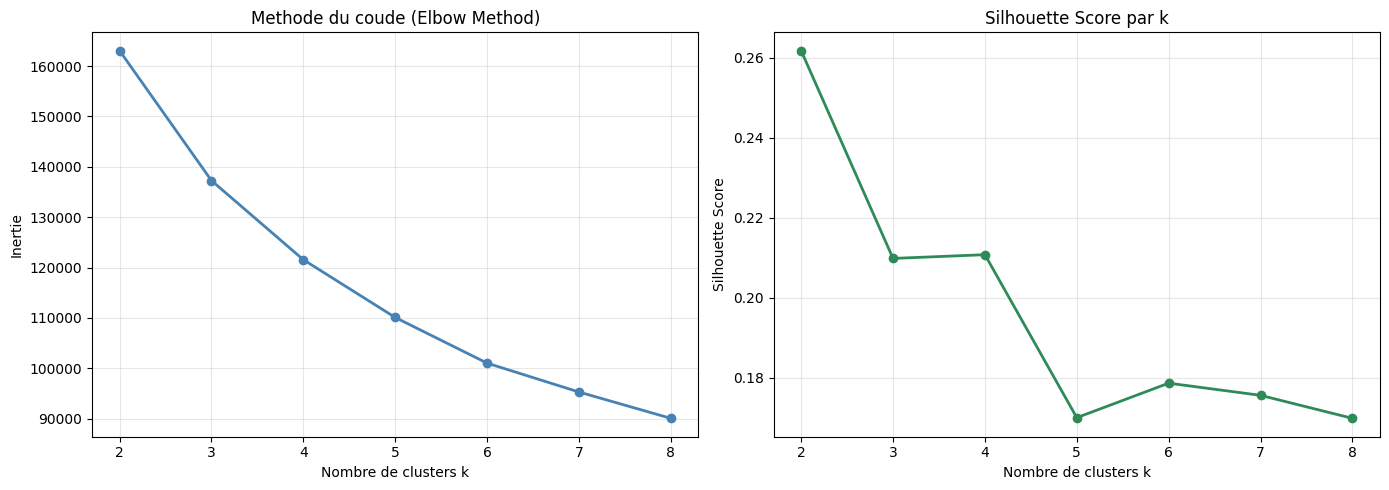

k optimal selon silhouette : 2


In [68]:
# Visualisation methode du coude + silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_values), inerties, marker='o', color='steelblue', lw=2)
axes[0].set_xlabel('Nombre de clusters k')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Methode du coude (Elbow Method)')
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_values), silhouettes, marker='o', color='seagreen', lw=2)
axes[1].set_xlabel('Nombre de clusters k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score par k')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

k_optimal = list(k_values)[silhouettes.index(max(silhouettes))]
print(f'k optimal selon silhouette : {k_optimal}')

On trace les deux courbes pour confirmer k=2. L'absence de coude net dans l'inertie indique que les données n'ont pas de groupes très séparés — courant sur des données financières hétérogènes.

## Etape 51 - KMeans final avec k optimal

In [69]:
k_final = k_optimal

kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
labels_kmeans = kmeans_final.fit_predict(X_cluster)

df_cluster['cluster_kmeans'] = labels_kmeans
df_cluster['loan_status']    = df_status.values

sil_final = silhouette_score(X_cluster, labels_kmeans, sample_size=5000, random_state=42)
db_final  = davies_bouldin_score(X_cluster, labels_kmeans)

print(f'KMeans final avec k={k_final}')
print(f'  Silhouette Score    : {sil_final:.4f}  (plus proche de 1 = meilleur)')
print(f'  Davies-Bouldin Score: {db_final:.4f}  (plus proche de 0 = meilleur)')
print()
print('Taille de chaque cluster :')
print(pd.Series(labels_kmeans).value_counts().sort_index())

KMeans final avec k=2
  Silhouette Score    : 0.2618  (plus proche de 1 = meilleur)
  Davies-Bouldin Score: 1.8594  (plus proche de 0 = meilleur)

Taille de chaque cluster :
0    21266
1     7366
Name: count, dtype: int64


KMeans avec k=2 est entraîné. silhouette_score et davies_bouldin_score quantifient la qualité de la partition. Un silhouette de 0.26 est modéré — les clusters se chevauchent partiellement.

## Etape 52 - Profil de chaque cluster KMeans

In [70]:
# Caracteristiques moyennes par cluster
profil_clusters = df_cluster.groupby('cluster_kmeans')[features_clustering + ['loan_status']].mean().round(2)
print('Profil moyen par cluster KMeans :')
print(profil_clusters.T.to_string())

Profil moyen par cluster KMeans :
cluster_kmeans                     0         1
person_age                     25.16     35.07
person_income               57188.93  87305.43
person_emp_length               3.91      7.30
loan_amnt                    8905.34  11820.58
loan_int_rate                  11.01     11.12
loan_percent_income             0.17      0.16
cb_person_cred_hist_length      4.09     10.70
loan_status                     0.23      0.18


groupby('cluster_kmeans').mean() calcule le profil moyen de chaque cluster. Le cluster 0 correspond aux jeunes emprunteurs (25 ans, 57 000$), le cluster 1 aux profils plus stables (35 ans, 87 000$).

Synthese des clusters KMeans :
                Taille  Taux de defaut (%)
cluster_kmeans                            
0                21266               23.05
1                 7366               17.65


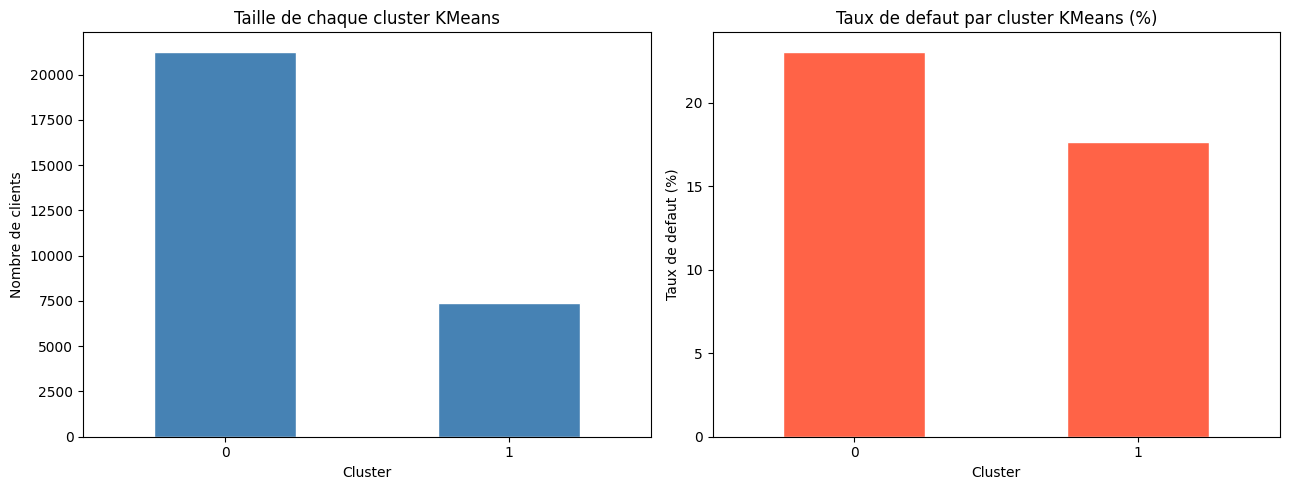

In [71]:
# Taux de defaut par cluster
taux_defaut = df_cluster.groupby('cluster_kmeans')['loan_status'].mean().round(4) * 100
taille = df_cluster.groupby('cluster_kmeans')['loan_status'].count()

synthese_kmeans = pd.DataFrame({
    'Taille': taille,
    'Taux de defaut (%)': taux_defaut
})
print('Synthese des clusters KMeans :')
print(synthese_kmeans.to_string())

# Graphique
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

taille.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Taille de chaque cluster KMeans')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Nombre de clients')
axes[0].tick_params(axis='x', rotation=0)

taux_defaut.plot(kind='bar', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('Taux de defaut par cluster KMeans (%)')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Taux de defaut (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

On croise les clusters avec loan_status pour voir si la segmentation capture du risque. Le taux de défaut est de 23% dans le cluster 0 contre 17% dans le cluster 1 — un écart de 6 points.

Variance expliquee par les 2 composantes PCA :
  PC1 : 28.9%
  PC2 : 23.3%
  Total : 52.2%


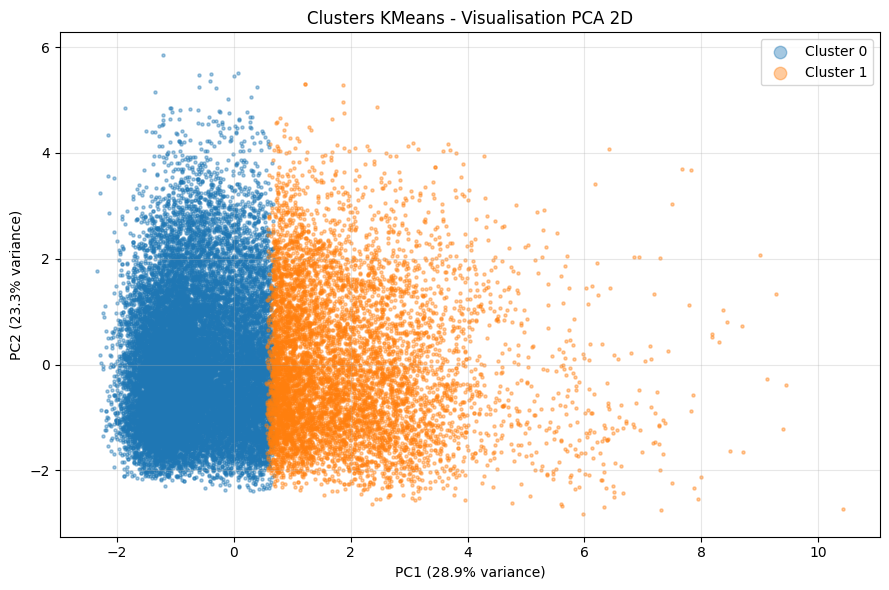

In [72]:
# Visualisation PCA 2D des clusters KMeans
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

variance_expliquee = pca.explained_variance_ratio_
print(f'Variance expliquee par les 2 composantes PCA :')
print(f'  PC1 : {variance_expliquee[0]*100:.1f}%')
print(f'  PC2 : {variance_expliquee[1]*100:.1f}%')
print(f'  Total : {sum(variance_expliquee)*100:.1f}%')

plt.figure(figsize=(9, 6))
couleurs = plt.cm.tab10.colors
for i in range(k_final):
    masque = labels_kmeans == i
    plt.scatter(X_pca[masque, 0], X_pca[masque, 1],
                s=5, alpha=0.4, color=couleurs[i], label=f'Cluster {i}')

plt.xlabel(f'PC1 ({variance_expliquee[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({variance_expliquee[1]*100:.1f}% variance)')
plt.title('Clusters KMeans - Visualisation PCA 2D')
plt.legend(markerscale=4)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

PCA(n_components=2) projette les 7 dimensions en 2 pour la visualisation. On trace chaque cluster dans une couleur différente. Le chevauchement visible explique le silhouette modéré.

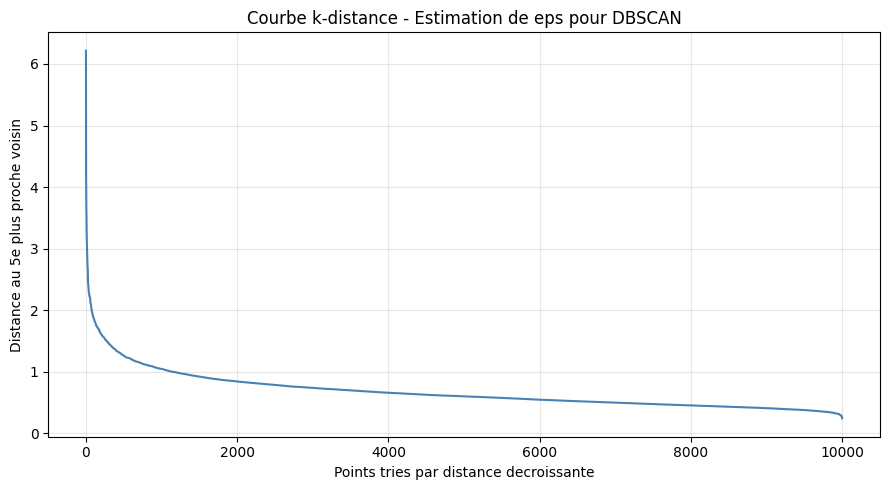

Lire le coude de la courbe pour choisir eps.
On utilise eps=1.5 et min_samples=10 comme point de depart.


In [73]:
from sklearn.neighbors import NearestNeighbors

# Estimation de eps via k-distance graph (k = min_samples - 1)
# On travaille sur un echantillon pour la rapidite
np.random.seed(42)
idx_sample = np.random.choice(len(X_cluster), size=min(10000, len(X_cluster)), replace=False)
X_sample = X_cluster[idx_sample]

nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_sample)
distances, _ = nn.kneighbors(X_sample)
distances_sorted = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(9, 5))
plt.plot(distances_sorted, color='steelblue', lw=1.5)
plt.xlabel('Points tries par distance decroissante')
plt.ylabel('Distance au 5e plus proche voisin')
plt.title('Courbe k-distance - Estimation de eps pour DBSCAN')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Lire le coude de la courbe pour choisir eps.')
print('On utilise eps=1.5 et min_samples=10 comme point de depart.')

NearestNeighbors calcule la distance de chaque point à son 5e voisin. On trie ces distances par ordre décroissant — le coude indique le bon eps. Au-delà, on connecte des points trop éloignés et les clusters deviennent trop larges.

In [74]:
# DBSCAN sur echantillon (pour la rapidite en demonstration)
dbscan = DBSCAN(eps=1.5, min_samples=10, n_jobs=-1)
labels_dbscan = dbscan.fit_predict(X_sample)

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_bruit       = (labels_dbscan == -1).sum()
pct_bruit     = n_bruit / len(labels_dbscan) * 100

print('Resultats DBSCAN')
print('=' * 35)
print(f'  Clusters trouves     : {n_clusters_db}')
print(f'  Points de bruit (-1) : {n_bruit} ({pct_bruit:.1f}%)')
print()
print('Distribution des labels :')
print(pd.Series(labels_dbscan).value_counts().sort_index())

Resultats DBSCAN
  Clusters trouves     : 1
  Points de bruit (-1) : 228 (2.3%)

Distribution des labels :
-1     228
 0    9772
Name: count, dtype: int64


DBSCAN(eps=1.5, min_samples=10) regroupe les points dont le voisinage de rayon 1.5 contient au moins 10 points. Les points sans voisins suffisants reçoivent le label -1 — ce sont les anomalies.

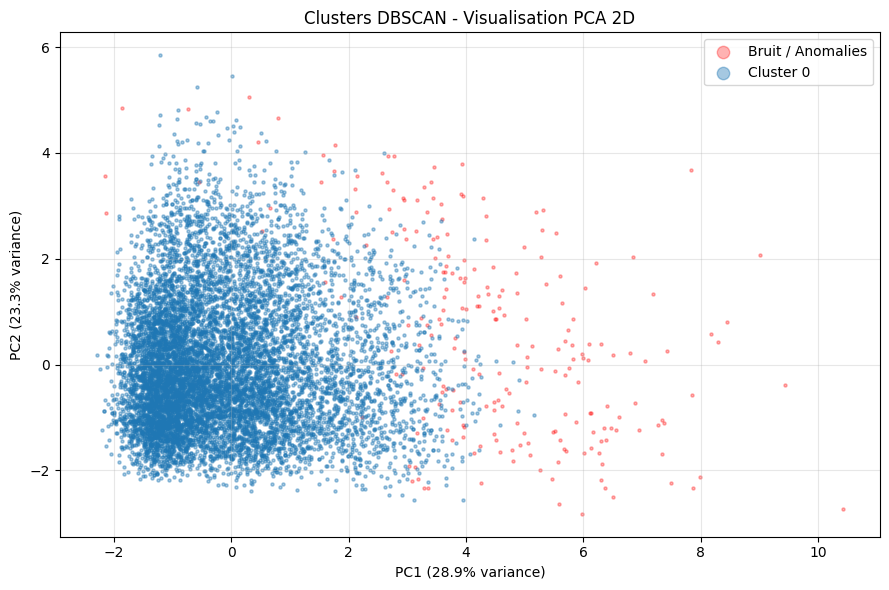

In [75]:
# Visualisation DBSCAN en PCA 2D
X_pca_sample = pca.transform(X_sample)

plt.figure(figsize=(9, 6))

labels_uniques = sorted(set(labels_dbscan))
for label in labels_uniques:
    masque = labels_dbscan == label
    if label == -1:
        plt.scatter(X_pca_sample[masque, 0], X_pca_sample[masque, 1],
                    s=5, alpha=0.3, color='red', label='Bruit / Anomalies')
    else:
        plt.scatter(X_pca_sample[masque, 0], X_pca_sample[masque, 1],
                    s=5, alpha=0.4, color=couleurs[label % 10], label=f'Cluster {label}')

plt.xlabel(f'PC1 ({variance_expliquee[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({variance_expliquee[1]*100:.1f}% variance)')
plt.title('Clusters DBSCAN - Visualisation PCA 2D')
plt.legend(markerscale=4, loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

pca.transform (sans fit) projette les données échantillonnées dans l'espace déjà appris. On colore les anomalies en rouge pour les distinguer du cluster principal.

## Etape 54 - Profil des anomalies DBSCAN

In [76]:
# Comparer les points de bruit vs les points normaux
df_sample = df_cluster.iloc[idx_sample].copy()
df_sample['label_dbscan'] = labels_dbscan
df_sample['est_anomalie'] = (labels_dbscan == -1).astype(int)

print('Profil moyen : clients normaux vs anomalies DBSCAN')
print()
comparaison_bruit = df_sample.groupby('est_anomalie')[features_clustering + ['loan_status']].mean().round(2)
comparaison_bruit.index = ['Clients normaux', 'Anomalies (bruit)']
print(comparaison_bruit.T.to_string())

Profil moyen : clients normaux vs anomalies DBSCAN

                            Clients normaux  Anomalies (bruit)
person_age                            27.20              45.46
person_income                      63807.41          116377.31
person_emp_length                      4.68               9.04
loan_amnt                           9439.12           16853.84
loan_int_rate                         11.04              12.10
loan_percent_income                    0.17               0.19
cb_person_cred_hist_length             5.47              16.85
loan_status                            0.22               0.28


On crée une colonne est_anomalie puis on compare les profils moyens entre 0 (normal) et 1 (anomalie) avec groupby().mean(). Les anomalies sont plus âgées (45 ans), ont un revenu plus élevé et empruntent des montants plus importants.

In [77]:
# Taux de defaut : normaux vs anomalies
taux_normal   = df_sample[df_sample['est_anomalie'] == 0]['loan_status'].mean() * 100
taux_anomalie = df_sample[df_sample['est_anomalie'] == 1]['loan_status'].mean() * 100

print('Taux de defaut :')
print(f'  Clients normaux   : {taux_normal:.2f}%')
print(f'  Anomalies (bruit) : {taux_anomalie:.2f}%')
print()
if taux_anomalie > taux_normal:
    print('Les clients identifies comme anomalies ont un taux de defaut plus eleve.')
    print('DBSCAN peut donc servir de signal d alerte complementaire au modele supervise.')
else:
    print('Les anomalies ne semblent pas liees au defaut sur ce sous-ensemble.')

Taux de defaut :
  Clients normaux   : 21.80%
  Anomalies (bruit) : 27.63%

Les clients identifies comme anomalies ont un taux de defaut plus eleve.
DBSCAN peut donc servir de signal d alerte complementaire au modele supervise.


On calcule le taux de défaut séparément pour les normaux et les anomalies. L'écart de 4 points confirme que DBSCAN a capturé une partie du signal de risque sans avoir accès à la variable cible.

## Etape 55 - Comparaison KMeans vs DBSCAN

In [78]:
# Les valeurs sont deja calculees dans les cellules precedentes
# On les regroupe ici pour la comparaison dans le markdown suivant
print('Variables disponibles pour la comparaison :')
print(f'  KMeans  : k={k_final}, silhouette={sil_final:.4f}, davies_bouldin={db_final:.4f}')
print(f'  DBSCAN  : clusters={n_clusters_db}, anomalies={n_bruit} ({pct_bruit:.1f}%)')

Variables disponibles pour la comparaison :
  KMeans  : k=2, silhouette=0.2618, davies_bouldin=1.8594
  DBSCAN  : clusters=1, anomalies=228 (2.3%)


KMeans nécessite de fixer k à l'avance et partitionne tous les points. DBSCAN détecte automatiquement les zones denses et isole les points atypiques. Les deux sont complémentaires : KMeans pour la segmentation, DBSCAN pour la détection d'anomalies.

## Etape 56 - Resume global du projet

Le projet couvre l'ensemble de la chaine data science : exploration, nettoyage, preprocessing, modelisation supervisee avec deux algorithmes, modelisation non supervisee, sauvegarde et exposition via API. Les deux modeles supervises sont accessibles via des endpoints distincts et versiones dans `api/models/`.